# MaxEnt Modeling — *Bipes biporus* MaxEnt Workflow

**Notebook 2 of 2 — San Diego Natural History Museum**

- Reads cleaned species points and final variable sets produced by `01_preprocessing.ipynb`
- Three variable sets are compared at default parameters; best set selected by AUC and AICc
- Grid search over feature types and regularization; final model outputs a cloglog suitability raster

### Roadmap
1. **Setup & Imports** — packages, paths, model parameters, variable auto-discovery, data loading
2. **Background Points** — sample random background points within the study area
3. **Default-Parameter Runs** — fit MaxEnt for each variable set at default parameters
4. **Model Comparison** — AUC, AICc, response curves, permutation importance, Jackknife
5. **Hyperparameter Tuning** — grid search over feature types, regularization, and background size
6. **Final Model** — tuned model, suitability raster, and result summary

### To reuse with different data

Sections 2–4 and 6 run automatically. All edits go in **§1** and optionally **§5**.

- **§1** — all project-specific parameters (paths, column names, model defaults); configure once before running
- **§5** — grid search parameter space (feature types, regularization multipliers, background sizes); adjust to widen or narrow the search

## 1. Setup & Imports

Run: `Kernel → Restart & Run All`

In [148]:
# 1.1 ── Install & version-check ────────────────────────────────────────────
import subprocess, sys

_EXACT_VERSIONS = {
    "numpy"       : "2.2.4",
    "pandas"      : "2.2.3",
    "geopandas"   : "1.1.3",
    "rasterio"    : "1.5.0",
    "matplotlib"  : "3.10.1",
    "seaborn"     : "0.13.2",
    "scipy"       : "1.15.2",
    "tqdm"        : "4.67.3",
    "scikit-learn": "1.5.2",
    "elapid"      : "1.0.3",
    "shapely"     : "2.1.2",
    "pyproj"      : "3.7.2",
}

_IMPORT_AS = {"scikit-learn": "sklearn"}

for pkg, exact_ver in _EXACT_VERSIONS.items():
    import_name = _IMPORT_AS.get(pkg, pkg)
    try:
        mod = __import__(import_name)
        installed = getattr(mod, "__version__", "0.0")
        if installed != exact_ver:
            print(f"  reinstalling {pkg} {installed} -> {exact_ver} ...")
            subprocess.check_call([sys.executable, "-m", "pip", "install",
                                    f"{pkg}=={exact_ver}", "-q"])
            print(f"  done: {pkg}=={exact_ver}")
        else:
            print(f"  OK  {pkg} {installed}")
    except ImportError:
        print(f"  installing: {pkg}=={exact_ver} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                                f"{pkg}=={exact_ver}", "-q"])
        print(f"  installed: {pkg}=={exact_ver}")


  OK  numpy 2.2.4
  OK  pandas 2.2.3
  OK  geopandas 1.1.3
  OK  rasterio 1.5.0
  OK  matplotlib 3.10.1
  OK  seaborn 0.13.2
  OK  scipy 1.15.2
  OK  tqdm 4.67.3
  OK  scikit-learn 1.5.2
  OK  elapid 1.0.3
  OK  shapely 2.1.2
  OK  pyproj 3.7.2


In [149]:
# ── Standard scientific ───────────────────────────────────────────────────────
import os, glob, re, math, warnings, json
import numpy  as np
import pandas as pd
import geopandas as gpd
from pyproj import CRS as _CRS

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display

# ── Raster / geo ──────────────────────────────────────────────────────────────
import rasterio

# ── Interpolation ─────────────────────────────────────────────────────────────
from scipy.interpolate import make_interp_spline

# ── MaxEnt / ML ───────────────────────────────────────────────────────────────
import elapid
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
%matplotlib inline

### 1.2 File Paths
> ✎ **Edit for every new project** — input/output directories, study area shapefile, and CSV column names.

In [150]:
# ── Input: preprocessed outputs from 01_preprocessing.ipynb ──────────────────
PROCESSED_DIR  = 'Processed'    # must match OUTPUT_DIR in 01_preprocessing.ipynb
OUTPUT_DIR     = 'Modeled'      # all outputs from this notebook

# ── Study area boundary (saved by 01_preprocessing.ipynb) ─────────────────────
STUDY_AREA_SHP = os.path.join(PROCESSED_DIR, 'study_area.shp')

# ── Column names in occurrences_cleaned.csv ───────────────────────────────────
LAT_COL     = 'Latitude'
LON_COL     = 'Longitude'
SPECIES_COL = 'Species'

# ── Coordinate system ─────────────────────────────────────────────────────────
TARGET_CRS = 'EPSG:32611'

os.makedirs(OUTPUT_DIR, exist_ok=True)

### 1.3 Model Parameters
> ✎ **Edit only when needed** — background sample size, train/test split, and MaxEnt defaults.

In [151]:
# ── Background sampling ───────────────────────────────────────────────────────
N_BACKGROUND_POINTS       = 10_000   # random points sampled within study area
TEST_FRACTION             = 0.25     # fraction of data withheld for evaluation
RANDOM_SEED               = 42

# ── Default MaxEnt configuration ──────────────────────────────────────────────
FEATURE_TYPES             = ['linear', 'quadratic']
                            # options: 'linear', 'quadratic', 'hinge', 'product', 'threshold'
REGULARIZATION_MULTIPLIER = 1.0      # >1 penalises complexity; increase to reduce overfitting
OUTPUT_TRANSFORM          = 'cloglog'  # calibrated [0, 1] habitat suitability

### 1.4 Point Data Loading & Validation

Species : Bipes biporus
Records : 49
CRS     : EPSG:32611


,Longitude,Latitude
0,-113.99917,28.28278
1,-113.94238,28.26377
2,-113.47800,28.24540
3,-110.33850,24.13083
4,-110.21670,23.45000


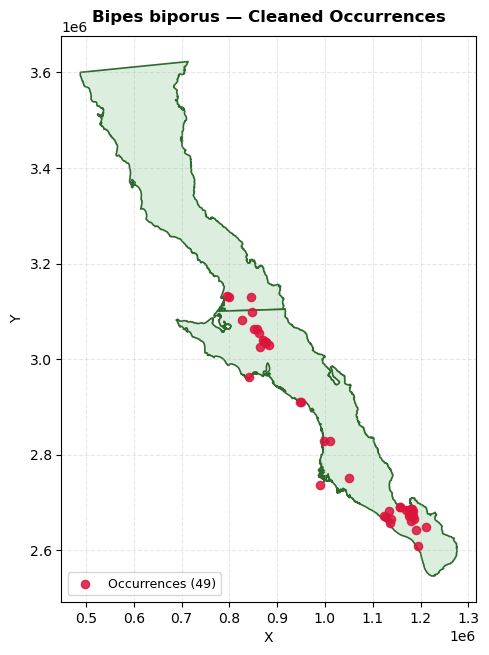

Saved → Modeled/01_Bipes_biporus_occurrences.png


In [152]:
# ── Load species occurrences ──────────────────────────────────────────────────
# CSV lon/lat are always WGS84 degrees — assign 4326 first, then reproject to TARGET_CRS.
occ = pd.read_csv(os.path.join(PROCESSED_DIR, 'species', 'occurrences_cleaned.csv'))
occ_gdf = gpd.GeoDataFrame(
    occ,
    geometry=gpd.points_from_xy(occ[LON_COL], occ[LAT_COL]),
    crs='EPSG:4326',
).to_crs(TARGET_CRS)
SPECIES_NAME = (occ[SPECIES_COL].iloc[0].strip()
                .replace(' ', '_').replace('(', '').replace(')', '').replace('/', '-'))

# ── Load study area boundary ──────────────────────────────────────────────────
study_area_raw = gpd.read_file(STUDY_AREA_SHP)
if study_area_raw.crs is None:
    study_area = study_area_raw.set_crs(TARGET_CRS)
elif study_area_raw.crs != _CRS(TARGET_CRS):
    study_area = study_area_raw.to_crs(TARGET_CRS)
else:
    study_area = study_area_raw

print(f'Species : {SPECIES_NAME.replace("_", " ")}')
print(f'Records : {len(occ_gdf)}')
print(f'CRS     : {occ_gdf.crs}')
display(occ_gdf[[LON_COL, LAT_COL]].head())

# ── Occurrence map ────────────────────────────────────────────────────────────
_is_geo = _CRS(TARGET_CRS).is_geographic
fig, ax = plt.subplots(figsize=(5, 9))
study_area.plot(ax=ax, color='#dceedd', edgecolor='#2d6a2d', linewidth=1.2)
occ_gdf.plot(ax=ax, color='crimson', markersize=35, zorder=3, alpha=0.85,
             label=f'Occurrences ({len(occ_gdf)})')
ax.set_title(f'{SPECIES_NAME.replace("_", " ")} — Cleaned Occurrences',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Longitude' if _is_geo else 'X')
ax.set_ylabel('Latitude'  if _is_geo else 'Y')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, f'01_{SPECIES_NAME}_occurrences.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

### 1.5 Raster Data Auto-Discovery & Validation

In [153]:
# ── Raster source directory map ────────────────────────────────────────────────
RASTER_SOURCE_DIRS = {
    d: os.path.join(PROCESSED_DIR, d)
    for d in sorted(os.listdir(PROCESSED_DIR))
    if os.path.isdir(os.path.join(PROCESSED_DIR, d)) and d != 'species'
}

# ── Scan final_vars_*.csv files and build variable set lookups ─────────────────
_csv_files = sorted(glob.glob(os.path.join(PROCESSED_DIR, 'final_vars_*.csv')))

VARIABLE_SETS     = {}   # {set_name: [var_keys]}
VAR_DISPLAY_NAMES = {}   # {var_key: full_name}
_var_to_path      = {}   # {var_key: raster_path}

for _csv in _csv_files:
    _set_name = re.sub(r'^final_vars_', '', os.path.splitext(os.path.basename(_csv))[0])
    _df = pd.read_csv(_csv)
    VARIABLE_SETS[_set_name] = _df['Variable'].tolist()
    for _, _row in _df.iterrows():
        VAR_DISPLAY_NAMES[_row['Variable']] = _row['Full name']
        _src_dir = RASTER_SOURCE_DIRS.get(_row['Source'], '')
        _var_to_path[_row['Variable']] = (
            os.path.join(_src_dir, _row['Filename']) if _src_dir else ''
        )

def raster_paths(var_list):
    """Return {var_key: path} for a list of variable keys."""
    return {v: _var_to_path[v] for v in var_list}

def _disp(var):
    """Human-readable label for a variable key."""
    return VAR_DISPLAY_NAMES.get(var, var)

def _safe_filename(text):
    return (text.replace(' ', '_').replace('(', '').replace(')', '')
                .replace('/', '-').replace('--', '-').strip('_'))

In [154]:
# ── Load raster metadata and validate all variable sets ───────────────────────
print(f'{"Set":<22}  {"vars":>5}  {"H × W":>13}  {"res (arcsec)":>13}  {"CRS"}')
print('─' * 72)
for set_name, var_list in VARIABLE_SETS.items():
    rp = raster_paths(var_list)
    with rasterio.open(next(iter(rp.values()))) as r:
        h, w = r.height, r.width
        res  = r.res[0]
        epsg = r.crs.to_epsg()
    print(f'{set_name:<22}  {len(rp):>5}  {h:>6} × {w:<6}  {res * 3600:>12.1f}  EPSG:{epsg}')
print()
print(f'{len(VARIABLE_SETS)} variable set(s) ready.')

Set                      vars          H × W   res (arcsec)  CRS
────────────────────────────────────────────────────────────────────────
BioClim_DEM                14    1521 × 1136       3185850.9  EPSG:32611
Combined                   24    1521 × 1136       3185850.9  EPSG:32611
Envirem                    11    1521 × 1136       3185850.9  EPSG:32611

3 variable set(s) ready.


## 2. Background Points

In [155]:
# ── Dissolve study area into a single sampling polygon ────────────────────────
study_area_dissolved = study_area.dissolve()
study_area_dissolved['geometry'] = study_area_dissolved.geometry.buffer(0)
study_area_geoseries = study_area_dissolved.geometry

# ── Area in km² ───────────────────────────────────────────────────────────────
if study_area_dissolved.crs.is_projected:
    area_km2 = study_area_dissolved.geometry.iloc[0].area / 1e6
else:
    _utm = study_area_dissolved.estimate_utm_crs()
    area_km2 = study_area_dissolved.to_crs(_utm).geometry.iloc[0].area / 1e6
bounds = study_area_dissolved.total_bounds

_xy = ('lon', 'lat') if not study_area_dissolved.crs.is_projected else ('X', 'Y')
print('Study-area polygon (background sampling boundary):')
print(f'  Geometry : {study_area_geoseries.iloc[0].geom_type}')
print(f'  Bounds   : {_xy[0]} [{bounds[0]:.2f}, {bounds[2]:.2f}]  {_xy[1]} [{bounds[1]:.2f}, {bounds[3]:.2f}]')
print(f'  Area     : {area_km2:,.0f} km²')

Study-area polygon (background sampling boundary):
  Geometry : MultiPolygon
  Bounds   : X [488182.10, 1276737.46]  Y [2546658.31, 3622578.11]
  Area     : 142,479 km²


Background points sampled: 10,000


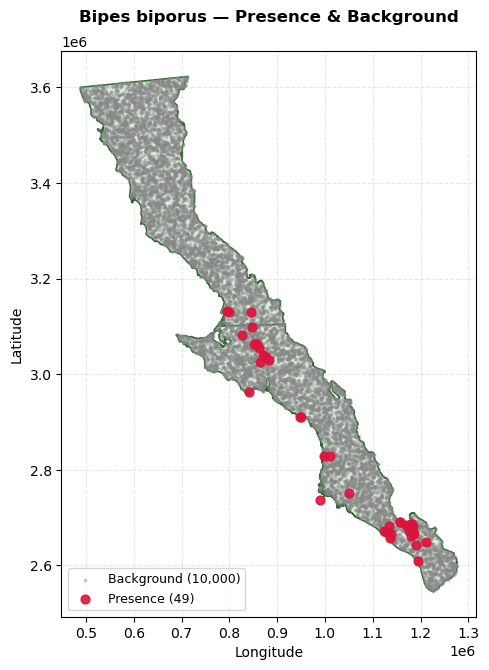

Saved → Modeled/02_background_sampling.png


In [156]:
# ── Sample random background points within the study area ─────────────────────
np.random.seed(RANDOM_SEED)
bg_geoseries   = elapid.sample_geoseries(study_area_geoseries, count=N_BACKGROUND_POINTS)
background_gdf = gpd.GeoDataFrame(geometry=bg_geoseries, crs=TARGET_CRS)
print(f'Background points sampled: {len(background_gdf):,}')

# ── Map: background (grey) and presence (red) on study area ───────────────────
fig, ax = plt.subplots(figsize=(5, 9))
study_area.plot(ax=ax, color='#dceedd', edgecolor='#2d6a2d', linewidth=1.2)
background_gdf.plot(ax=ax, color='#888888', markersize=3, alpha=0.35, zorder=2,
            label=f'Background ({len(background_gdf):,})')
occ_gdf.plot(ax=ax, color='crimson', markersize=40, zorder=3, alpha=0.9,
             label=f'Presence ({len(occ_gdf)})')

ax.set_title(f'{SPECIES_NAME.replace("_", " ")} — Presence & Background',
             fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='lower left', fontsize=9)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()

out_path = os.path.join(OUTPUT_DIR, '02_background_sampling.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

`N_BACKGROUND_POINTS` random background points sampled uniformly within the Baja Peninsula. They represent the environmental conditions accessible to the species and anchor the MaxEnt null distribution.

In [157]:
# ── Annotate presence and background points for all variable sets ──────────────
ANNOTATED_SETS = {}   # {set_name: (X, y, var_list)}

for set_name, var_list in VARIABLE_SETS.items():
    rp          = raster_paths(var_list)
    raster_list = list(rp.values())

    pres_ann = elapid.annotate(occ_gdf[['geometry']], raster_list,
                               labels=var_list, drop_na=True, quiet=True)
    bg_ann   = elapid.annotate(background_gdf, raster_list,
                               labels=var_list, drop_na=True, quiet=True)

    X = pd.concat([pres_ann[var_list].astype(float),
                   bg_ann  [var_list].astype(float)], ignore_index=True)
    y = np.concatenate([np.ones(len(pres_ann)), np.zeros(len(bg_ann))])

    ANNOTATED_SETS[set_name] = (X, y, var_list)
    print(f'{set_name:<22}: presence {len(pres_ann):>4} | background {len(bg_ann):>6}'
          f' | matrix {X.shape[0]:>6} × {X.shape[1]}')

BioClim_DEM           : presence   44 | background   9732 | matrix   9776 × 14
Combined              : presence   44 | background   9732 | matrix   9776 × 24
Envirem               : presence   44 | background   9732 | matrix   9776 × 11


## 3. Default-Parameter Runs

Each variable set is fitted with the default parameters from §1.3.

In [158]:
# ── Model-run helpers ────────────────────────────────────────────────────

def _smooth_roc(fpr, tpr, n=300):
    """Interpolate a step-wise ROC curve to a smooth line (cubic spline)."""
    fpr_u, idx = np.unique(fpr, return_index=True)
    tpr_u = tpr[idx]
    if len(fpr_u) < 4:
        return fpr, tpr
    spl = make_interp_spline(fpr_u, tpr_u, k=3)
    fpr_s = np.linspace(fpr_u[0], fpr_u[-1], n)
    tpr_s = np.clip(spl(fpr_s), 0, 1)
    return fpr_s, tpr_s


def compute_aicc(model, X_presence):
    """AICc = -2*logL + 2K + 2K(K+1)/(n-K-1)  (Warren & Seifert 2011).

    logL              -- sum of log(cloglog) at presence test locations.
    n_nonzero_params  -- number of non-zero model coefficients; this is the k
                         in AIC/AICc, counting only the parameters the lasso
                         kept non-zero (penalised complexity proxy).
    """
    y_hat   = np.clip(model.predict(X_presence), 1e-10, 1.0)
    log_lik = float(np.sum(np.log(y_hat)))

    try:
        est  = model.estimator
        coef = (est[-1].coef_ if hasattr(est, '__getitem__') else est.coef_)
        n_nonzero_params = int(np.sum(np.abs(coef) > 1e-8))
    except Exception:
        n_nonzero_params = X_presence.shape[1]

    n     = len(X_presence)
    aic   = -2.0 * log_lik + 2.0 * n_nonzero_params
    denom = max(n - n_nonzero_params - 1, 1)
    aicc  = aic + (2.0 * n_nonzero_params * (n_nonzero_params + 1)) / denom
    return round(aicc, 2), n_nonzero_params


def run_default_model(X, y, var_names, label, fig_name=None,
                      feature_types=None, beta_multiplier=None,
                      transform=None, test_fraction=None, random_seed=None):
    """Fit a MaxEnt model, evaluate, and store all diagnostics in one dict."""
    ft_cfg        = feature_types   if feature_types   is not None else FEATURE_TYPES
    beta_cfg      = beta_multiplier if beta_multiplier is not None else REGULARIZATION_MULTIPLIER
    transform_cfg = transform       if transform       is not None else OUTPUT_TRANSFORM
    test_frac     = test_fraction   if test_fraction   is not None else TEST_FRACTION
    rand_seed     = random_seed     if random_seed     is not None else RANDOM_SEED
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_frac, stratify=y, random_state=rand_seed,
    )

    model = elapid.MaxentModel(
        feature_types   = ft_cfg,
        beta_multiplier = beta_cfg,
        transform       = transform_cfg,
    )
    model.fit(X_train, y_train)

    y_prob_train = model.predict(X_train)
    y_prob_test  = model.predict(X_test)
    train_auc    = roc_auc_score(y_train, y_prob_train)
    test_auc     = roc_auc_score(y_test,  y_prob_test)
    fpr, tpr, _  = roc_curve(y_test, y_prob_test)

    pres_idx       = np.where(y_test == 1)[0]
    X_pres_test    = X_test.iloc[pres_idx]
    aicc, n_params = compute_aicc(model, X_pres_test)

    def _roc_scorer(est, X, y):
        return roc_auc_score(y, est.predict(X))

    perm = permutation_importance(
        model, X_test, y_test,
        n_repeats=10, scoring=_roc_scorer, random_state=rand_seed,
    )
    perm_imp_df = (
        pd.DataFrame({
            'Variable'  : var_names,
            'importance': perm.importances_mean,
            'std'       : perm.importances_std,
        })
        .sort_values('importance', ascending=False)
        .reset_index(drop=True)
    )

    # ── ROC plot (smoothed) ────────────────────────────────────────────────
    fpr_s, tpr_s = _smooth_roc(fpr, tpr)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.plot(fpr_s, tpr_s, color='steelblue', lw=2,
            label=f'Test AUC = {test_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.text(0.55, 0.10, f'Train AUC = {train_auc:.4f}',
            transform=ax.transAxes, fontsize=9, color='grey')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {label}', fontsize=11, fontweight='bold')
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    if fig_name:
        _roc_out = os.path.join(OUTPUT_DIR, fig_name)
        plt.savefig(_roc_out, dpi=150, bbox_inches='tight')
        print(f'ROC saved -> {_roc_out}')
    plt.show()

    print(f'\n{label}')
    print(f'  Train AUC : {train_auc:.4f}')
    print(f'  Test AUC  : {test_auc:.4f}')
    print(f'  AICc      : {aicc:.1f}  (k = {n_params} non-zero parameters)')

    return dict(
        model        = model,        label       = label,
        var_names    = var_names,
        X_train      = X_train,      X_test      = X_test,
        y_train      = y_train,      y_test      = y_test,
        y_prob_train = y_prob_train, y_prob_test = y_prob_test,
        train_auc    = train_auc,    test_auc    = test_auc,
        aicc         = aicc,         n_params    = n_params,
        fpr          = fpr,          tpr         = tpr,
        perm_imp_df  = perm_imp_df,
    )


── BioClim_DEM ──


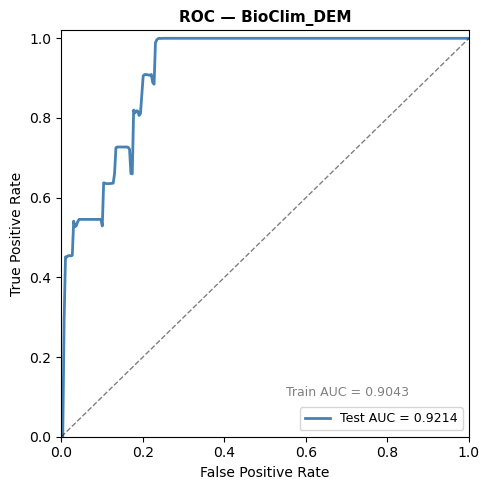


BioClim_DEM
  Train AUC : 0.9043
  Test AUC  : 0.9214
  AICc      : 204.5  (k = 9 non-zero parameters)

── Combined ──


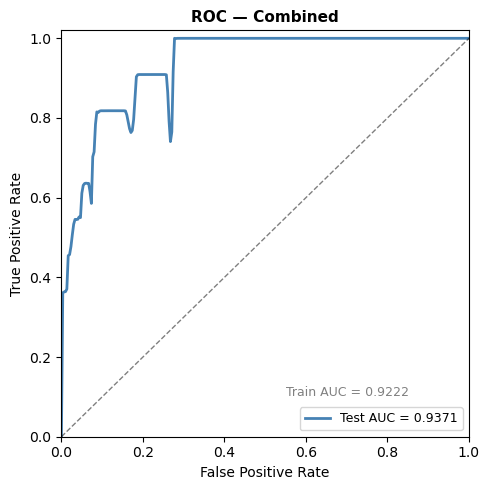


Combined
  Train AUC : 0.9222
  Test AUC  : 0.9371
  AICc      : 728.7  (k = 18 non-zero parameters)

── Envirem ──


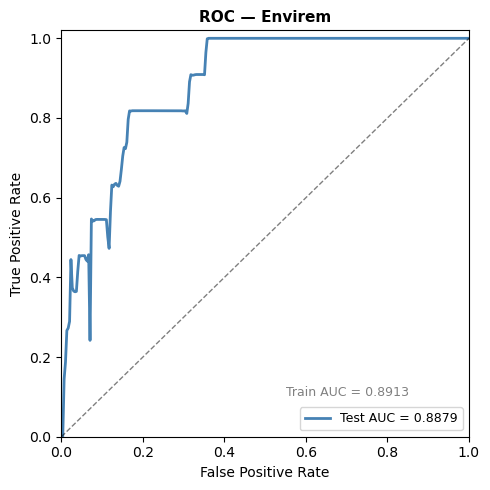


Envirem
  Train AUC : 0.8913
  Test AUC  : 0.8879
  AICc      : 60.7  (k = 7 non-zero parameters)


In [159]:
# Fits MaxEnt at default parameters for every variable set in VARIABLE_SETS.
DEFAULT_RESULTS = {}

for set_name, (X, y, var_list) in ANNOTATED_SETS.items():
    print(f'\n── {set_name} ──')
    DEFAULT_RESULTS[set_name] = run_default_model(X, y, var_list, set_name)

## 4. Model Comparison

### 4.1 AUC / AICc

Set,n vars,Train AUC,Test AUC,AICc,k (params)
BioClim_DEM,14,0.904300,0.921400,204.500000,9
Combined,24,0.922200,0.937100,728.700000,18
Envirem,11,0.891300,0.887900,60.700000,7


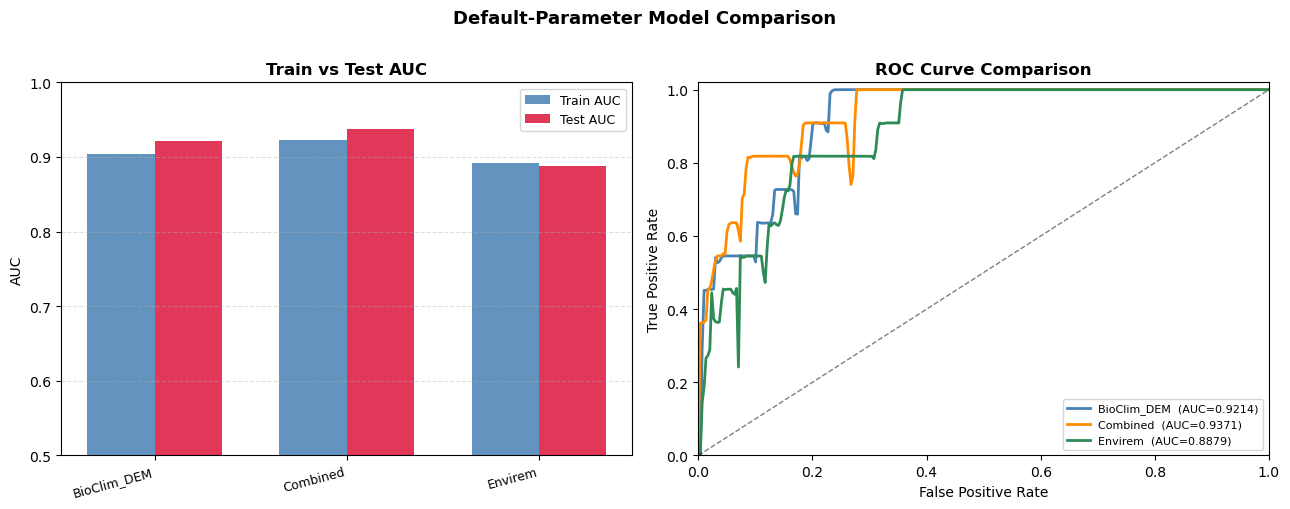

Saved → Modeled/03_default_runs_comparison.png


In [160]:
# -- AUC / AICc comparison + select best set -------------------------
results_list = list(DEFAULT_RESULTS.values())

comp_df = pd.DataFrame([{
    'Set'        : r['label'],
    'n vars'     : len(r['var_names']),
    'Train AUC'  : round(r['train_auc'], 4),
    'Test AUC'   : round(r['test_auc'],  4),
    'AICc'       : round(r['aicc'],      1),
    'k (params)' : r['n_params'],
} for r in results_list])
display(comp_df.style.hide(axis='index'))
print()

# -- comparison plot
_pal    = ['steelblue', 'darkorange', 'seagreen', 'purple', 'brown']
_colors = [_pal[i % len(_pal)] for i in range(len(results_list))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x, w = np.arange(len(comp_df)), 0.35
ax.bar(x - w/2, comp_df['Train AUC'], width=w, label='Train AUC',
       color='steelblue', alpha=0.85)
ax.bar(x + w/2, comp_df['Test AUC'],  width=w, label='Test AUC',
       color='crimson',   alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels([r['label'] for r in results_list],
                   fontsize=9, rotation=15, ha='right')
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('AUC')
ax.set_title('Train vs Test AUC', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', ls='--', alpha=0.4)

ax = axes[1]
for r, c in zip(results_list, _colors):
    _fs, _ts = _smooth_roc(r['fpr'], r['tpr'])
    ax.plot(_fs, _ts, color=c, lw=2,
            label=f'{r["label"]}  (AUC={r["test_auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison', fontweight='bold')
ax.legend(loc='lower right', fontsize=8)

plt.suptitle('Default-Parameter Model Comparison',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, '03_default_runs_comparison.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

In [161]:
# -- select best set (primary: test AUC; tiebreak: lower AICc) ----------------
best_idx        = comp_df['Test AUC'].idxmax()
BEST_SET_RESULT = results_list[best_idx]
BEST_SET_LABEL  = BEST_SET_RESULT['label']
BEST_VARS       = BEST_SET_RESULT['var_names']
BEST_RASTER_PATHS = raster_paths(BEST_VARS)

print(f'\nBest variable set : {BEST_SET_LABEL}')
print(f'  Test AUC : {BEST_SET_RESULT["test_auc"]:.4f}'
      f'  |  AICc : {BEST_SET_RESULT["aicc"]:.1f}'
      f'  |  n vars : {len(BEST_VARS)}')


Best variable set : Combined
  Test AUC : 0.9371  |  AICc : 728.7  |  n vars : 24


Best variable set balances high test AUC with low AICc. A high train AUC paired with a much lower test AUC signals overfitting.

### 4.2 Response Curves

In [162]:
def plot_response_curves(result, top_n=None, save_path=None):
    """Marginal response curves sorted by permutation importance."""
    model, label = result['model'], result['label']
    var_names    = result['var_names']
    X_test       = result['X_test']
    imp_df       = result['perm_imp_df']

    n_plot   = len(var_names) if top_n is None else min(top_n, len(var_names))
    top_vars = imp_df.head(n_plot)['Variable'].tolist()

    X_med = pd.DataFrame([X_test[var_names].median()], columns=var_names)

    ncols = 4
    nrows = math.ceil(n_plot / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(4 * ncols, 3.5 * nrows), squeeze=False)
    ax_flat = axes.flatten()

    for ax, var in zip(ax_flat, top_vars):
        x_range = np.linspace(X_test[var].min(), X_test[var].max(), 100)
        X_marg  = pd.concat([X_med] * 100, ignore_index=True)
        X_marg[var] = x_range
        y_pred  = model.predict(X_marg)
        ax.plot(x_range, y_pred, color='steelblue', lw=2)
        ax.fill_between(x_range, y_pred, alpha=0.15, color='steelblue')
        ax.margins(y=0.08)
        ax.set_ylabel('Suitability', fontsize=10)
        ax.set_title(_disp(var), fontsize=11, fontweight='bold')
        ax.grid(True, ls='--', alpha=0.3)

    for ax in ax_flat[n_plot:]:
        ax.set_visible(False)

    title_suffix = '' if top_n is None else f'  (top {n_plot} by perm. importance)'
    plt.suptitle(f'Response Curves — {label}{title_suffix}',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved -> {save_path}')
    plt.show()

Saved -> Modeled/04_default_BioClim_DEM_response_curves.png


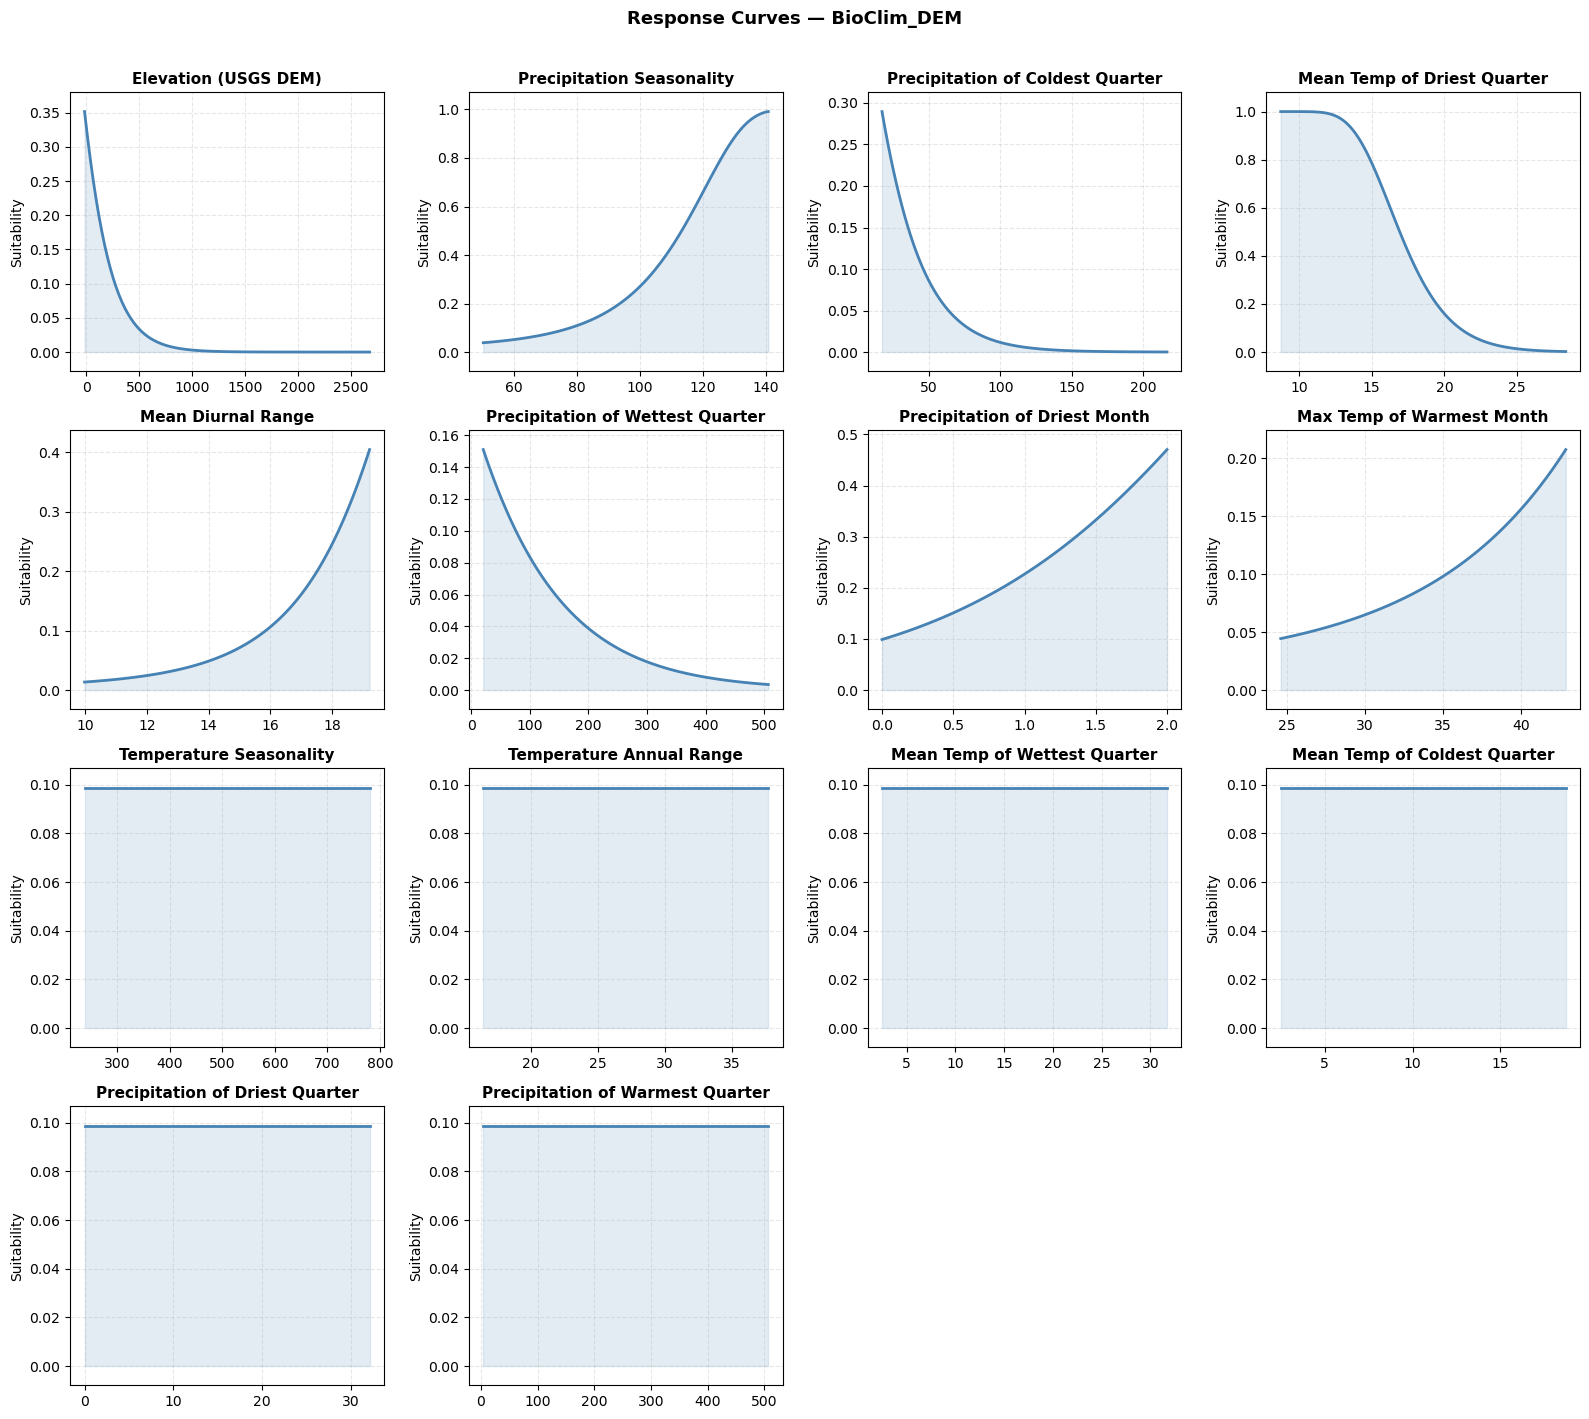

Saved -> Modeled/04_default_Combined_response_curves.png


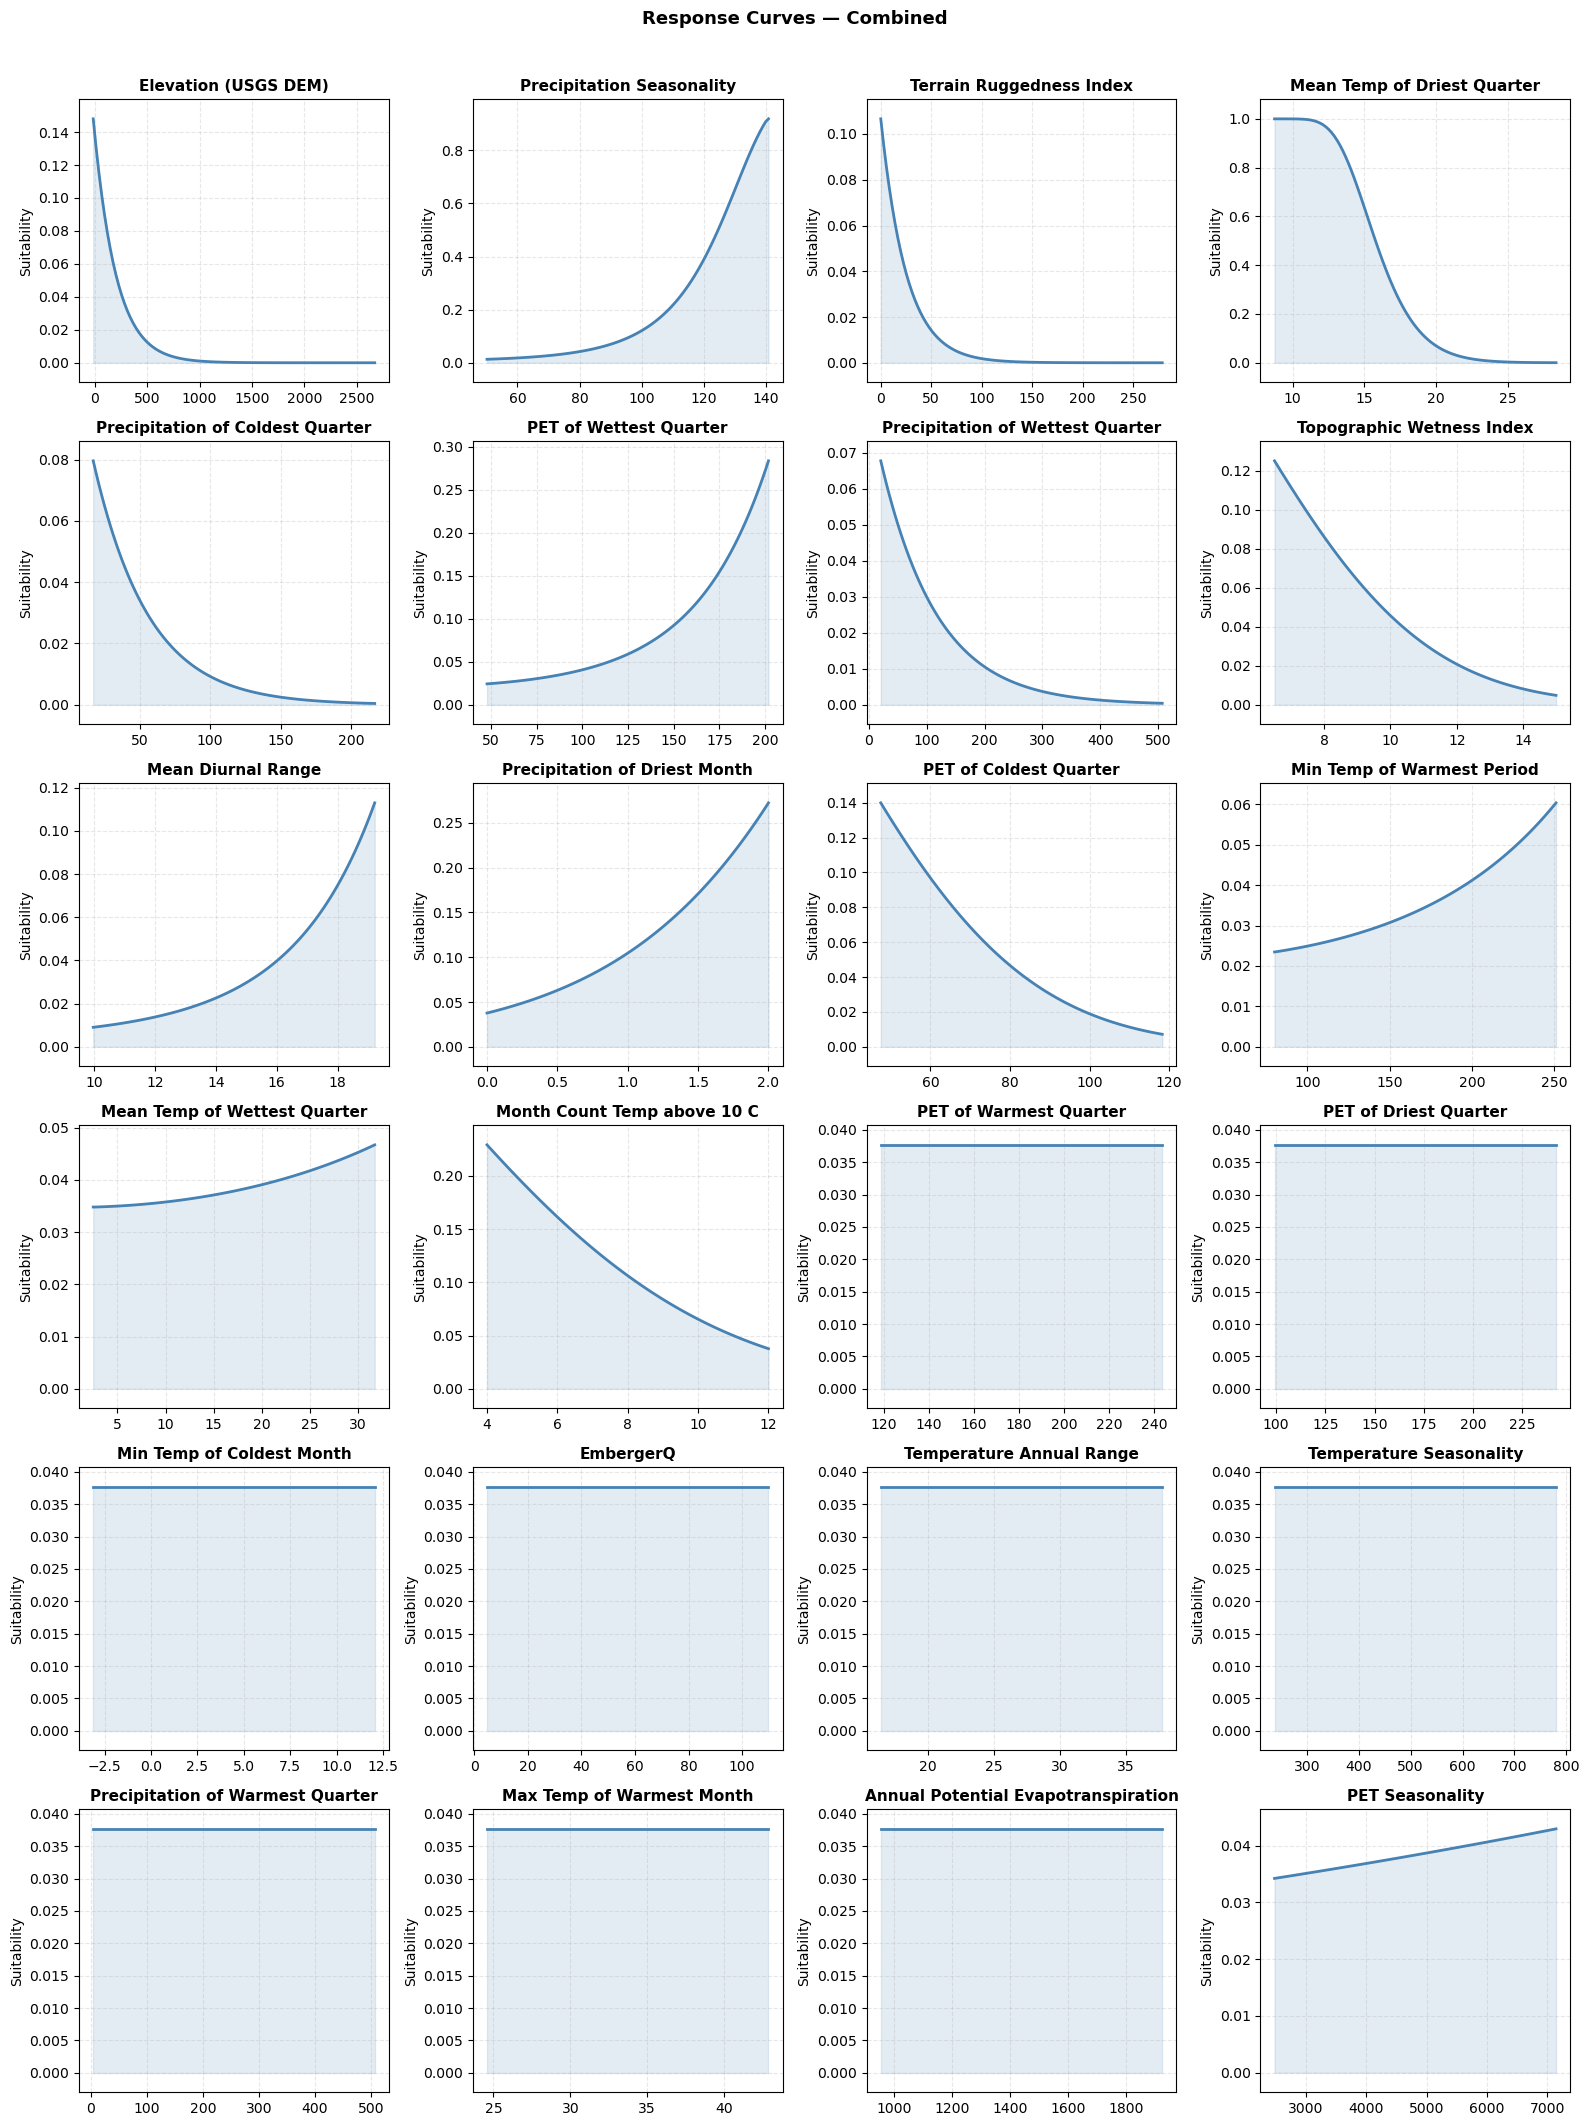

Saved -> Modeled/04_default_Envirem_response_curves.png


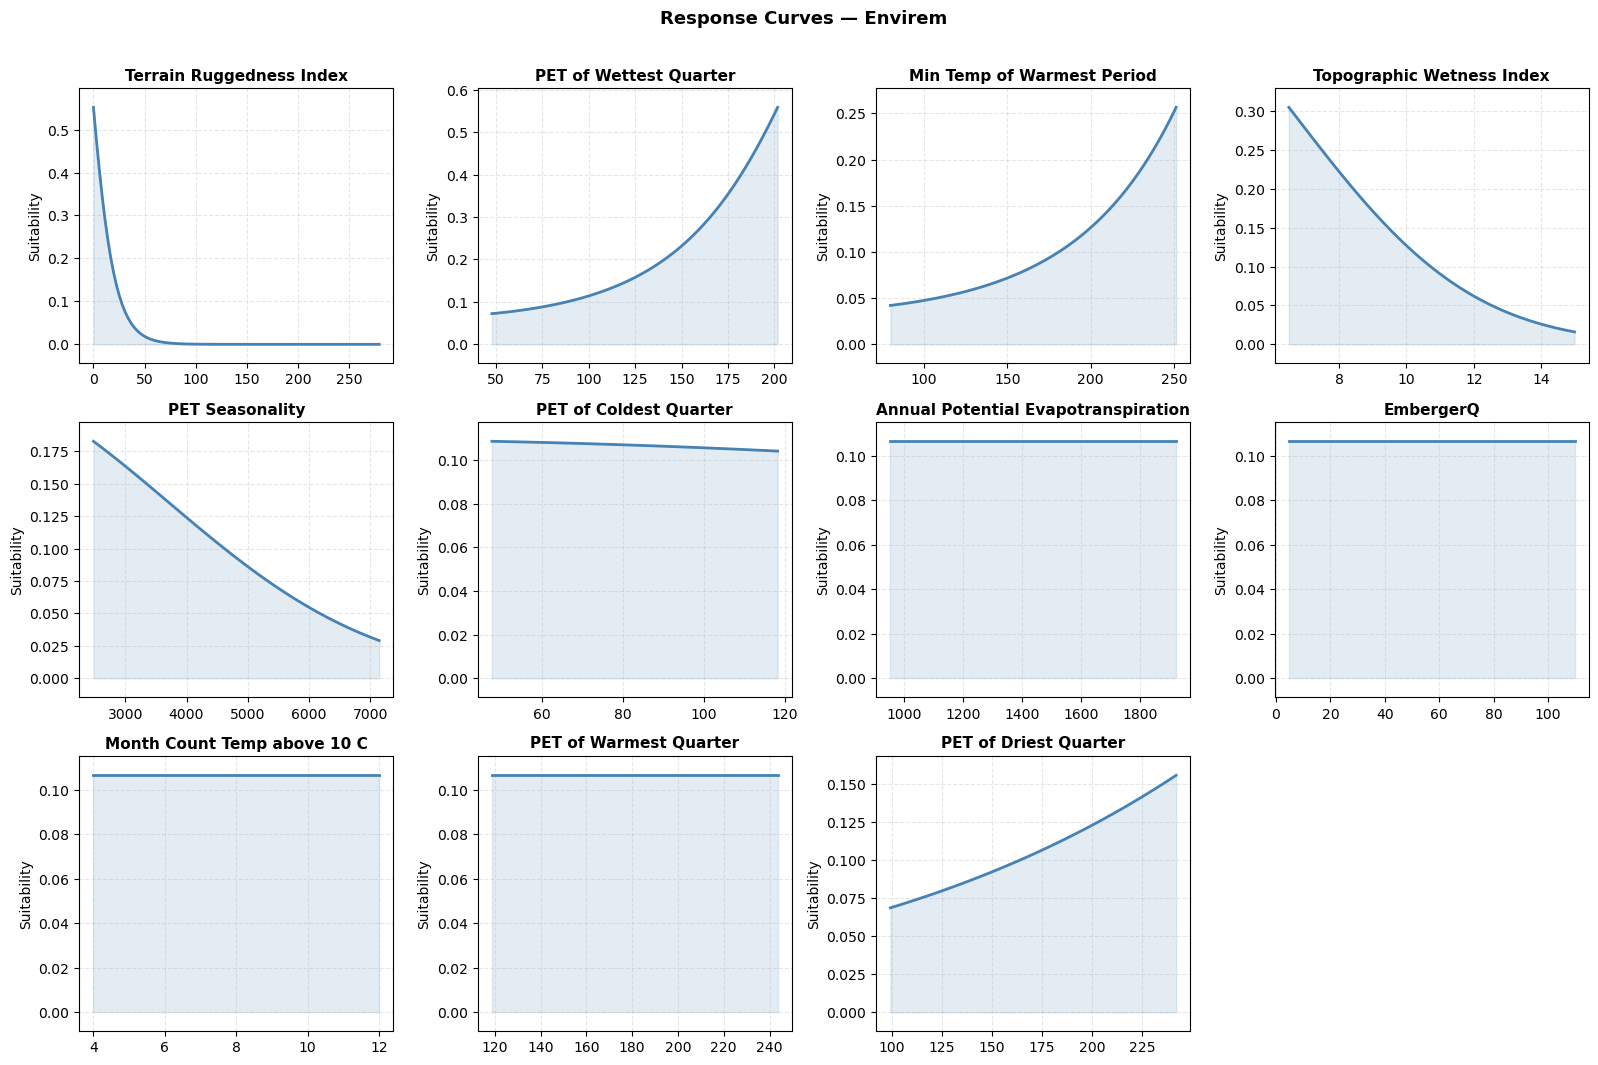

In [163]:
# 4.2 — Response curves for all default variable sets
for r in results_list:
    fn  = f'04_default_{_safe_filename(r["label"])}_response_curves.png'
    out = os.path.join(OUTPUT_DIR, fn)
    plot_response_curves(r, save_path=out)

Each curve holds all other variables at their test-set median and sweeps the target across its observed range. Erratic shapes may indicate collinearity or insufficient regularisation.

### 4.3a Variable Importance (Permutation)

Permutation importance: shuffling a variable and measuring the AUC drop shows how much each predictor contributes to discriminative power.

In [164]:
def plot_permutation_importance(results_list):
    """Side-by-side horizontal bar charts of mean permutation importance (10 repeats)."""
    n        = len(results_list)
    max_vars = max(len(r['var_names']) for r in results_list)
    fig, axes = plt.subplots(1, n,
                             figsize=(7 * n, max(6, max_vars * 0.50)),
                             squeeze=False)
    _pal   = ['steelblue', 'darkorange', 'seagreen', 'purple', 'brown']
    colors = [_pal[i % len(_pal)] for i in range(n)]

    for ax, r, c in zip(axes[0], results_list, colors):
        df = r['perm_imp_df'].copy()
        df['label'] = df['Variable'].map(_disp)
        ax.barh(df['label'], df['importance'], color=c, alpha=0.85)
        ax.invert_yaxis()
        ax.set_xlabel('Mean AUC decrease', fontsize=13)
        ax.set_title(r['label'], fontsize=13, fontweight='bold')
        ax.tick_params(labelsize=11)
        ax.grid(axis='x', ls='--', alpha=0.4)
        ax.legend(handles=[Patch(facecolor=c, alpha=0.85, label='Mean AUC decrease')],
                  loc='lower right', fontsize=11, frameon=True)

    plt.suptitle('Permutation Variable Importance', fontsize=15, fontweight='bold')
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, '05_default_variable_permutation_importance.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out_path}')

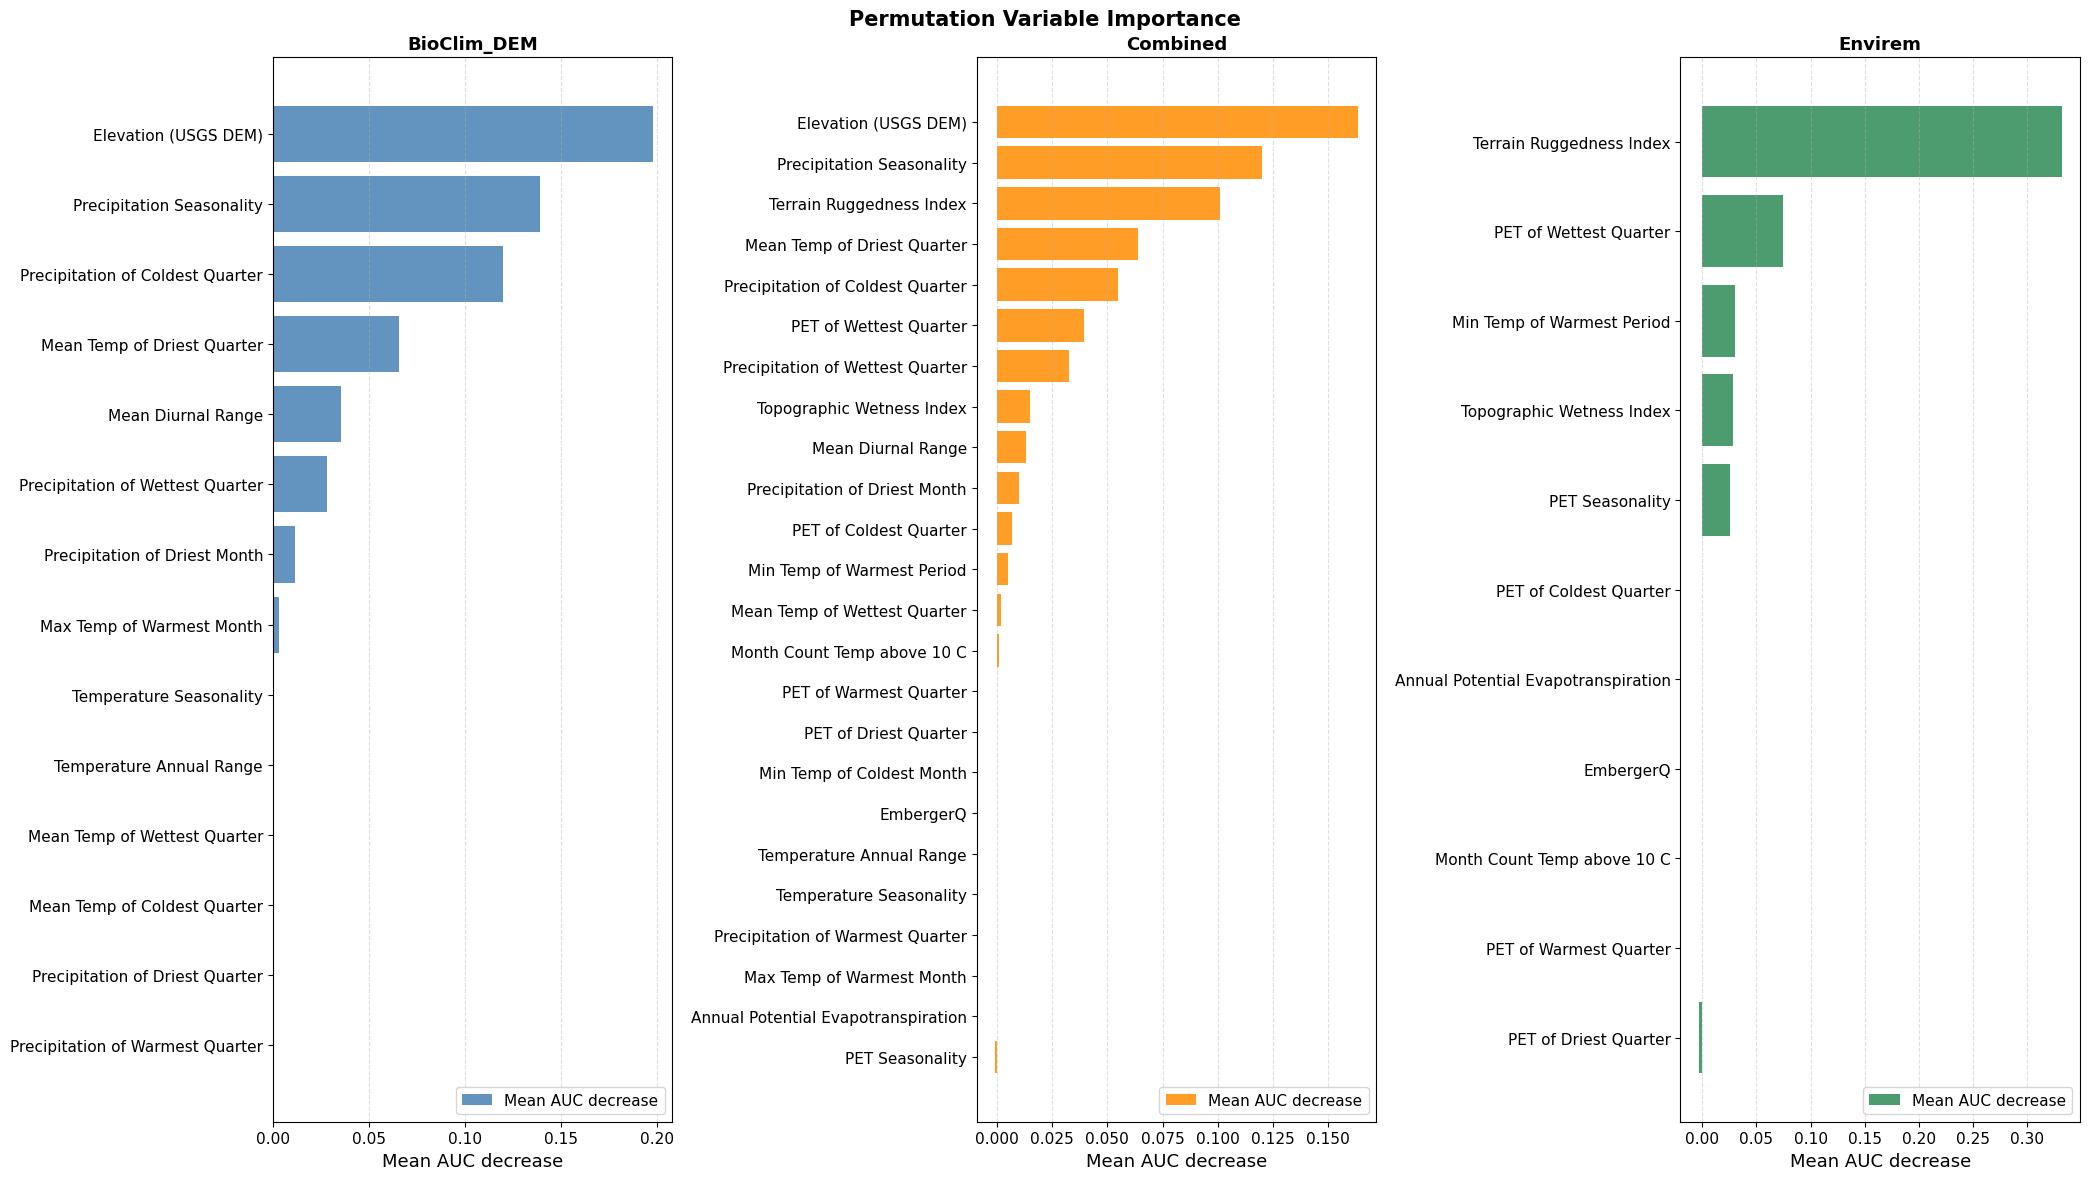

Saved → Modeled/05_default_variable_permutation_importance.png


In [165]:
# 5.3a — Permutation importance (all variable sets)
plot_permutation_importance(results_list)

### 4.3b Jackknife Variable Importance

Jackknife: fit one model with only each variable, and one with each variable left out. A high "only this" AUC means the variable carries independent signal; a low "without this" AUC means the variable is hard to replace.

In [166]:
def _jackknife_data(result):
    """Compute only/without AUCs for all variables in one result dict."""
    var_names = result['var_names']
    seed      = RANDOM_SEED
    X_all = pd.concat([result['X_train'], result['X_test']], ignore_index=True)
    y_all = np.concatenate([result['y_train'], result['y_test']])
    ft_cfg   = getattr(result['model'], 'feature_types',   FEATURE_TYPES)
    beta_cfg = getattr(result['model'], 'beta_multiplier', REGULARIZATION_MULTIPLIER)

    def _fit(X_sub):
        Xtr, Xte, ytr, yte = train_test_split(
            X_sub, y_all, test_size=TEST_FRACTION, stratify=y_all, random_state=seed)
        m = elapid.MaxentModel(feature_types=ft_cfg, beta_multiplier=beta_cfg,
                               transform=OUTPUT_TRANSFORM)
        m.fit(Xtr, ytr)
        return roc_auc_score(yte, m.predict(Xte))

    only_aucs, without_aucs = {}, {}
    for var in tqdm(var_names, desc=f'Jackknife — {result["label"]}'):
        only_aucs[var]    = _fit(X_all[[var]])
        without_aucs[var] = _fit(X_all[[v for v in var_names if v != var]])
    return only_aucs, without_aucs


def _ax_jk_legend(ax, bar_color, full_auc):
    """Add legend to a jackknife axes panel."""
    legend_elements = [
        Patch(facecolor=bar_color, alpha=0.85, label='Only this variable'),
        Patch(facecolor='#c0392b', alpha=0.85, label='Without this variable'),
        Line2D([0], [0], color='black', lw=1.5, ls='--',
               label=f'Full model AUC = {full_auc:.4f}'),
    ]
    ax.legend(handles=legend_elements, loc='upper center',
              bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=10, frameon=True)


def plot_jackknife_all_sets(results_list, save_path=None):
    """Side-by-side jackknife panels for every result in results_list."""
    n        = len(results_list)
    max_vars = max(len(r['var_names']) for r in results_list)
    fig, axes = plt.subplots(1, n,
                             figsize=(9 * n, max(6, max_vars * 0.52)),
                             squeeze=False)
    _pal   = ['steelblue', 'darkorange', 'seagreen', 'purple', 'brown']
    colors = [_pal[i % len(_pal)] for i in range(n)]

    for ax, r, c in zip(axes[0], results_list, colors):
        only_aucs, without_aucs = _jackknife_data(r)
        full_auc  = r['test_auc']
        var_names = r['var_names']
        vars_sorted   = sorted(var_names, key=lambda v: only_aucs[v], reverse=True)
        labels_sorted = [_disp(v) for v in vars_sorted]
        y_pos = np.arange(len(vars_sorted))

        ax.barh(y_pos - 0.2, [only_aucs[v]    for v in vars_sorted], height=0.35,
                color=c,       alpha=0.85)
        ax.barh(y_pos + 0.2, [without_aucs[v] for v in vars_sorted], height=0.35,
                color='#c0392b', alpha=0.85)
        ax.axvline(full_auc, color='black', lw=1.5, ls='--')
        ax.text(full_auc + 0.002, len(vars_sorted) - 0.5,
                f'AUC={full_auc:.4f}', fontsize=9, va='top', color='black')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels_sorted, fontsize=11)
        ax.invert_yaxis()
        ax.set_xlabel('Test AUC', fontsize=13)
        ax.set_title(r['label'], fontsize=13, fontweight='bold')
        ax.tick_params(axis='x', labelsize=11)
        ax.grid(axis='x', ls='--', alpha=0.4)
        _ax_jk_legend(ax, c, full_auc)

    plt.suptitle('Jackknife Variable Importance', fontsize=15, fontweight='bold')
    plt.tight_layout()
    out = save_path or os.path.join(OUTPUT_DIR, '06_default_jackknife_importance.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')


def run_jackknife(result, save_path=None):
    """Single-result jackknife plot (used for final model)."""
    only_aucs, without_aucs = _jackknife_data(result)
    label     = result['label']
    full_auc  = result['test_auc']
    var_names = result['var_names']
    vars_sorted   = sorted(var_names, key=lambda v: only_aucs[v], reverse=True)
    labels_sorted = [_disp(v) for v in vars_sorted]
    y_pos = np.arange(len(vars_sorted))

    fig, ax = plt.subplots(figsize=(9, max(6, len(vars_sorted) * 0.52)))
    ax.barh(y_pos - 0.2, [only_aucs[v]    for v in vars_sorted], height=0.35,
            color='steelblue', alpha=0.85)
    ax.barh(y_pos + 0.2, [without_aucs[v] for v in vars_sorted], height=0.35,
            color='#c0392b',   alpha=0.85)
    ax.axvline(full_auc, color='black', lw=1.5, ls='--')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels_sorted, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlabel('Test AUC', fontsize=13)
    ax.set_title(f'Jackknife Variable Importance — {label}', fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', labelsize=11)
    ax.grid(axis='x', ls='--', alpha=0.4)
    _ax_jk_legend(ax, 'steelblue', full_auc)
    plt.tight_layout()
    out = save_path or os.path.join(OUTPUT_DIR, '12_final_model_jackknife.png')
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved → {out}')

Jackknife — BioClim_DEM:   0%|          | 0/14 [00:00<?, ?it/s]

Jackknife — Combined:   0%|          | 0/24 [00:00<?, ?it/s]

Jackknife — Envirem:   0%|          | 0/11 [00:00<?, ?it/s]

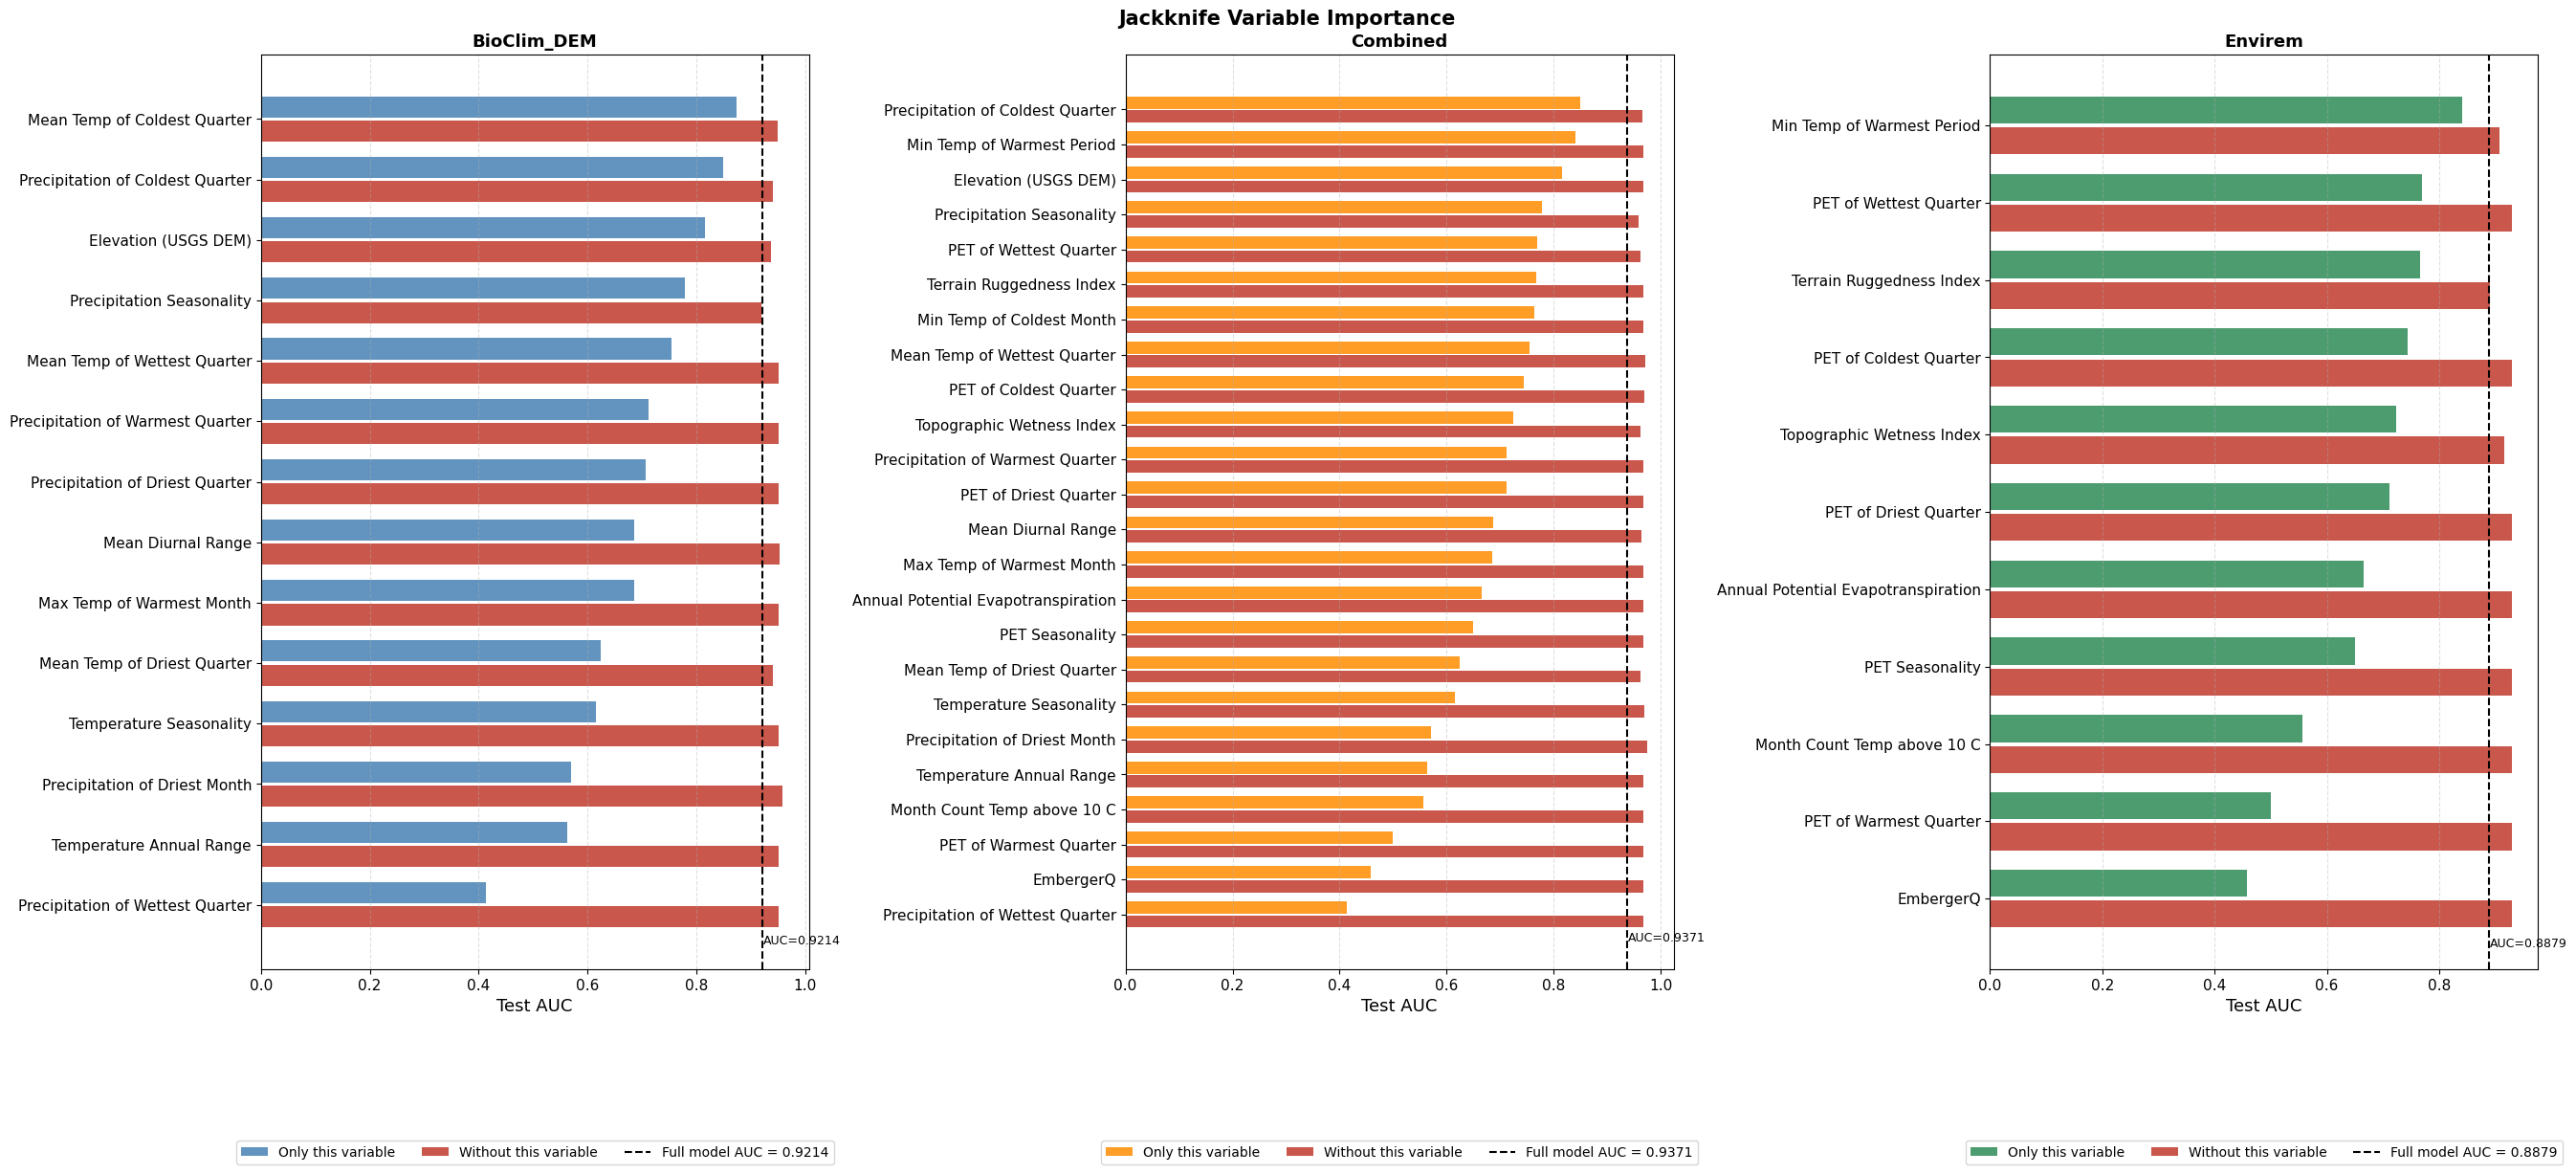

Saved → Modeled/06_default_jackknife_importance.png


In [167]:
# 5.3b — Jackknife for all default variable sets
jk_path = os.path.join(OUTPUT_DIR, '06_default_jackknife_importance.png')
plot_jackknife_all_sets(results_list, save_path=jk_path)

## 5. Hyperparameter Tuning

### 5.1 Grid Parameter Space
> ✎ **Edit to widen or narrow the search** — feature types, regularization values, background sizes, and variable subset sizes.

In [168]:
# ── Grid search switch ────────────────────────────────────────────────────────
RUN_GRIDSEARCH = True    # set False to skip the search and reload a cached CSV
GS_CSV         = os.path.join(OUTPUT_DIR, 'gridsearch_results.csv')

# ── Search space ──────────────────────────────────────────────────────────────
# combinations of response-curve feature types to test — more types allow more complex shapes
FEATURE_GRID = [
    ['linear', 'quadratic'],
    ['linear', 'quadratic', 'hinge', 'product'],
]

# regularization strength — higher → simpler model, less overfitting
BETA_GRID = [0.5, 1.0, 1.5, 2.0, 3.0]   

# background point counts to test — more → better null distribution, slower
N_BG_GRID = [5_000, 10_000, 20_000]   

# test subsets of the top-N most important variables; values ≥ n_vars auto-skipped    
VAR_TOP_N = [10, 18]      
                 
# ─────────────────────────────────────────────────────────────────────────────

imp_ranked = BEST_SET_RESULT['perm_imp_df']['Variable'].tolist()
_n_best    = len(BEST_VARS)

VAR_SETS = {}
for n in VAR_TOP_N:
    if n < _n_best:
        VAR_SETS[f'top {n}'] = imp_ranked[:n]
VAR_SETS[f'all {_n_best}'] = BEST_VARS

total_combos = len(FEATURE_GRID) * len(BETA_GRID) * len(N_BG_GRID) * len(VAR_SETS)
print(f'Grid: {len(FEATURE_GRID)} feature sets  ×  {len(BETA_GRID)} beta values'
      f'  ×  {len(N_BG_GRID)} bg sizes  ×  {len(VAR_SETS)} variable sets'
      f'  =  {total_combos} combinations')
print()
print('Feature sets:')
for i, ft in enumerate(FEATURE_GRID, 1):
    print(f'  {i}. {ft}')
print(f'Beta multipliers : {BETA_GRID}')
print(f'n_background     : {[f"{n:,}" for n in N_BG_GRID]}')
print('Variable sets:')
for label, vset in VAR_SETS.items():
    print(f'  {label:<12}: {len(vset)} variables')

Grid: 2 feature sets  ×  5 beta values  ×  3 bg sizes  ×  3 variable sets  =  90 combinations

Feature sets:
  1. ['linear', 'quadratic']
  2. ['linear', 'quadratic', 'hinge', 'product']
Beta multipliers : [0.5, 1.0, 1.5, 2.0, 3.0]
n_background     : ['5,000', '10,000', '20,000']
Variable sets:
  top 10      : 10 variables
  top 18      : 18 variables
  all 24      : 24 variables


### 5.2 Run Grid Search

In [169]:
if RUN_GRIDSEARCH:
    gs_results = []
    total_runs = len(N_BG_GRID) * len(VAR_SETS) * len(FEATURE_GRID) * len(BETA_GRID)

    with tqdm(total=total_runs, desc='Grid search', unit='model') as pbar:
        for n_bg in N_BG_GRID:
            np.random.seed(RANDOM_SEED)
            bg_points     = elapid.sample_geoseries(study_area_geoseries, count=n_bg)
            bg_points_gdf = gpd.GeoDataFrame(geometry=bg_points, crs=TARGET_CRS)

            pres_annotated = elapid.annotate(occ_gdf[['geometry']],
                                              list(BEST_RASTER_PATHS.values()),
                                              labels=BEST_VARS, drop_na=True, quiet=True)
            bg_annotated   = elapid.annotate(bg_points_gdf,
                                              list(BEST_RASTER_PATHS.values()),
                                              labels=BEST_VARS, drop_na=True, quiet=True)

            X_gs = pd.concat([pres_annotated[BEST_VARS].astype(float),
                              bg_annotated  [BEST_VARS].astype(float)], ignore_index=True)
            y_gs = np.concatenate([np.ones(len(pres_annotated)), np.zeros(len(bg_annotated))])

            X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
                X_gs, y_gs, test_size=TEST_FRACTION, stratify=y_gs, random_state=RANDOM_SEED)

            for var_label, var_set in VAR_SETS.items():
                X_tr_sub = X_train_gs[var_set]
                X_te_sub = X_test_gs[var_set]

                for feat_types in FEATURE_GRID:
                    feat_label = '+'.join(feat_types)
                    for beta_val in BETA_GRID:
                        m = elapid.MaxentModel(
                            feature_types   = feat_types,
                            beta_multiplier = beta_val,
                            transform       = OUTPUT_TRANSFORM,
                        )
                        m.fit(X_tr_sub, y_train_gs)
                        tr_auc = roc_auc_score(y_train_gs, m.predict(X_tr_sub))
                        te_auc = roc_auc_score(y_test_gs,  m.predict(X_te_sub))
                        gs_results.append({
                            'var_set'        : var_label,
                            'n_background'   : n_bg,
                            'feature_types'  : feat_label,
                            'beta_multiplier': beta_val,
                            'train_auc'      : round(tr_auc, 4),
                            'test_auc'       : round(te_auc, 4),
                            'auc_gap'        : round(tr_auc - te_auc, 4),
                        })
                        pbar.set_postfix(n_bg=f'{n_bg:,}', vars=var_label,
                                         ft=feat_label[:12], b=beta_val,
                                         te=f'{te_auc:.4f}')
                        pbar.update(1)

    gs_df = (pd.DataFrame(gs_results)
             .sort_values('test_auc', ascending=False)
             .reset_index(drop=True))
    gs_df.to_csv(GS_CSV, index=False)
    print(f'Grid search complete ({total_runs} models). Best test AUC: {gs_df["test_auc"].iloc[0]:.4f}')
    print(f'Saved → {GS_CSV}')

else:
    if os.path.exists(GS_CSV):
        gs_df = pd.read_csv(GS_CSV)
        print(f'Loaded cached results from {GS_CSV}  ({len(gs_df)} rows)')
    else:
        raise FileNotFoundError(
            f'No cached results at {GS_CSV}. Set RUN_GRIDSEARCH = True in §5.1 to run the search.')

Grid search:   0%|          | 0/90 [00:00<?, ?model/s]

Grid search complete (90 models). Best test AUC: 0.9678
Saved → Modeled/gridsearch_results.csv


### 5.3 Results

var_set,n_background,feature_types,beta_multiplier,train_auc,test_auc,auc_gap
top 10,20000,linear+quadratic,0.500000,0.924700,0.967800,-0.043100
top 10,20000,linear+quadratic,1.000000,0.924200,0.966000,-0.041800
top 10,20000,linear+quadratic,1.500000,0.923400,0.965000,-0.041600
top 10,20000,linear+quadratic,2.000000,0.922700,0.964200,-0.041500
top 10,20000,linear+quadratic,3.000000,0.921600,0.963200,-0.041500
top 18,20000,linear+quadratic,3.000000,0.919800,0.959200,-0.039400
top 18,20000,linear+quadratic,2.000000,0.920600,0.959100,-0.038500
top 18,20000,linear+quadratic,1.500000,0.921100,0.958800,-0.037700
top 18,20000,linear+quadratic,1.000000,0.921700,0.958800,-0.037000
top 18,20000,linear+quadratic,0.500000,0.922700,0.958700,-0.036100


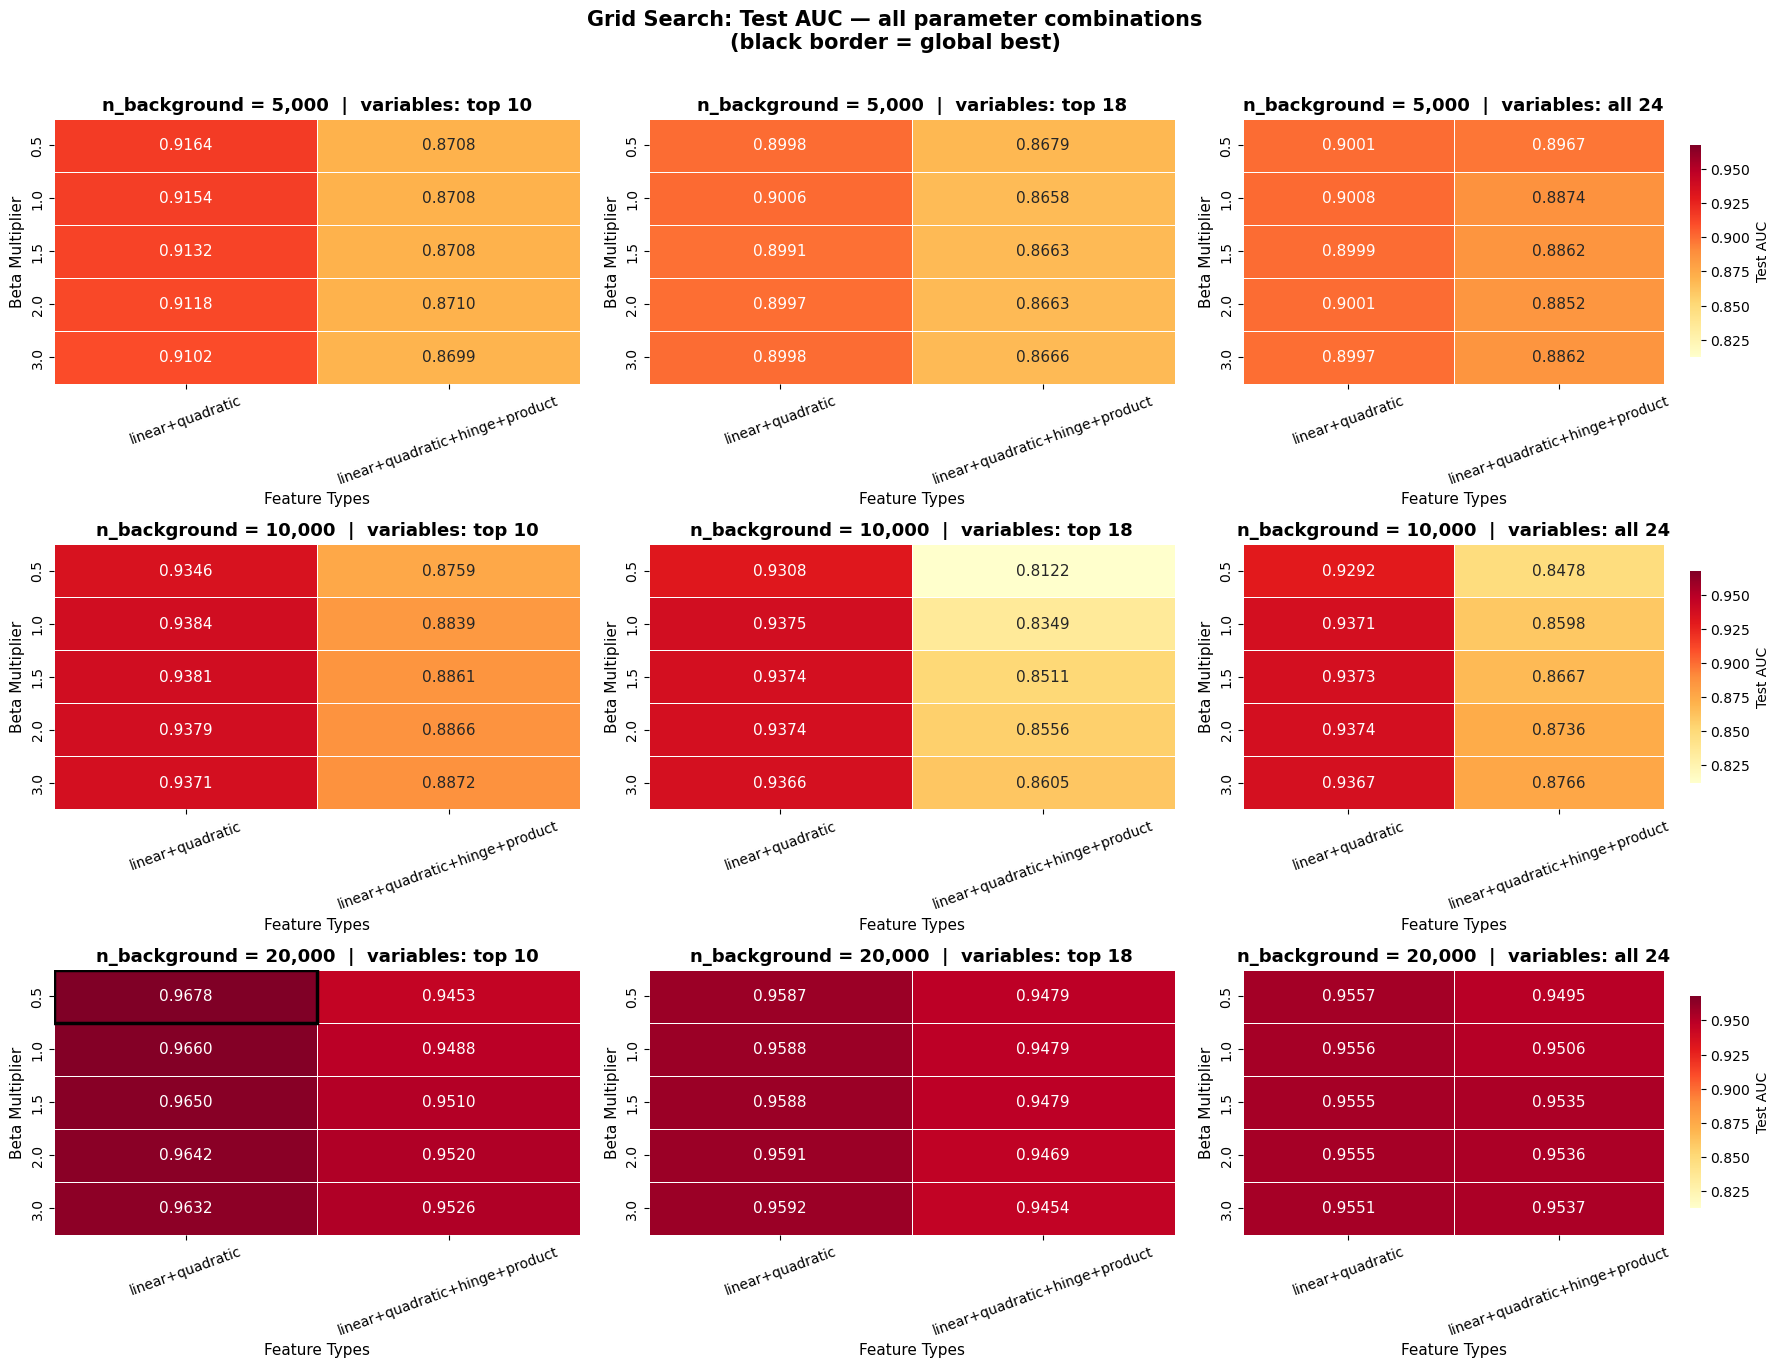

Saved -> Modeled/07_hyperparameter_gridsearch.png


In [170]:
# — Comprehensive grid-search results panel (all parameter combinations) ──
display(gs_df.head(10).style.hide(axis='index'))
print()

if len(gs_df) > 1:
    n_bgs         = sorted(gs_df['n_background'].unique())
    var_set_order = list(VAR_SETS.keys())
    feat_order    = sorted(gs_df['feature_types'].unique())
    vmin_global   = gs_df['test_auc'].min()
    vmax_global   = gs_df['test_auc'].max()
    best_val      = gs_df['test_auc'].max()

    nrows = len(n_bgs)
    ncols = len(var_set_order)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 4.5 * nrows),
                             squeeze=False)

    for row_idx, n_bg in enumerate(n_bgs):
        for col_idx, var_label in enumerate(var_set_order):
            ax = axes[row_idx, col_idx]
            sub = gs_df[(gs_df['n_background'] == n_bg) &
                        (gs_df['var_set'] == var_label)]
            if sub.empty:
                ax.set_visible(False)
                continue

            # only keep feature-type columns that actually appear in this sub-group
            _local_feat_order = [f for f in feat_order if f in sub['feature_types'].values]
            pivot = sub.pivot_table(
                index='beta_multiplier',
                columns='feature_types',
                values='test_auc',
            ).reindex(columns=_local_feat_order)

            show_cbar = (col_idx == ncols - 1)
            hm_kws = dict(annot=True, fmt='.4f', cmap='YlOrRd',
                          vmin=vmin_global, vmax=vmax_global,
                          ax=ax, linewidths=0.5, cbar=show_cbar,
                          annot_kws={'fontsize': 11})
            if show_cbar:
                hm_kws['cbar_kws'] = {'label': 'Test AUC', 'shrink': 0.8}
            sns.heatmap(pivot, **hm_kws)

            # mark global best cell with a black border
            best_rows = gs_df[(gs_df['n_background'] == n_bg) &
                               (gs_df['var_set'] == var_label) &
                               (gs_df['test_auc'] == best_val)]
            for _, br in best_rows.iterrows():
                ft = br['feature_types']
                if ft in list(pivot.columns):
                    r_i = list(pivot.index).index(br['beta_multiplier'])
                    c_i = list(pivot.columns).index(ft)
                    ax.add_patch(plt.Rectangle(
                        (c_i, r_i), 1, 1, fill=False,
                        edgecolor='black', lw=2.5, zorder=5))

            ax.set_title(f'n_background = {n_bg:,}  |  variables: {var_label}',
                         fontsize=13, fontweight='bold')
            ax.set_xlabel('Feature Types', fontsize=11)
            ax.set_ylabel('Beta Multiplier', fontsize=11)
            ax.tick_params(axis='both', labelsize=10)
            ax.tick_params(axis='x', rotation=20)

    plt.suptitle('Grid Search: Test AUC — all parameter combinations\n(black border = global best)',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, '07_hyperparameter_gridsearch.png')
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {out_path}')

In [171]:
# -- Extract best parameters; update BEST_VARS if grid search chose a subset --
best_row = gs_df.iloc[0]

BEST_FEATURES  = best_row['feature_types'].split('+')
BEST_BETA      = float(best_row['beta_multiplier'])
BEST_N_BG      = int(best_row['n_background'])
BEST_VAR_LABEL = best_row['var_set']

BEST_VARS = VAR_SETS[BEST_VAR_LABEL]
BEST_RASTER_PATHS = raster_paths(BEST_VARS)

print('Best parameters (from grid search):')
print(f'  var_set         : {BEST_VAR_LABEL}  ({len(BEST_VARS)} variables)')
print(f'  feature_types   : {BEST_FEATURES}')
print(f'  beta_multiplier : {BEST_BETA}')
print(f'  n_background    : {BEST_N_BG:,}')
print(f'  test_auc        : {best_row["test_auc"]:.4f}')
print(f'  auc_gap         : {best_row["auc_gap"]:+.4f}')
print()
print('Variables in winning subset:')
for v in BEST_VARS:
    print(f'  {v}')

Best parameters (from grid search):
  var_set         : top 10  (10 variables)
  feature_types   : ['linear', 'quadratic']
  beta_multiplier : 0.5
  n_background    : 20,000
  test_auc        : 0.9678
  auc_gap         : -0.0431

Variables in winning subset:
  gt30w140n40
  bio_15
  tri
  bio_9
  bio_19
  PETWettestQuarter
  bio_16
  topoWet
  bio_2
  bio_14


## 6. Final Model

Fits MaxEnt with the best variable set and hyperparameters identified in Sections 4–5.

### 6.1 Run with Optimal Parameters

Fresh background sampled: 20,000
Final Model: presence   44 | background  19510 | matrix  19554 × 10
ROC saved -> Modeled/08_final_model_roc.png


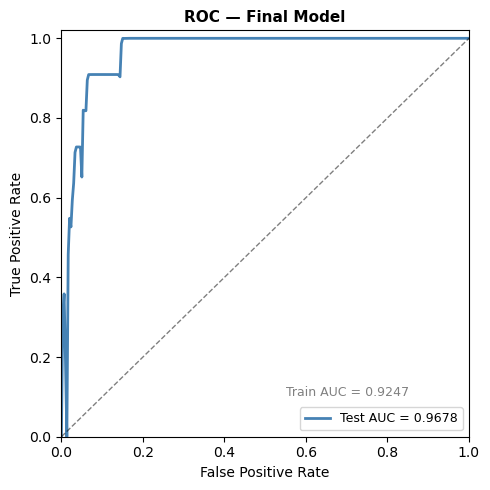


Final Model
  Train AUC : 0.9247
  Test AUC  : 0.9678
  AICc      : 291.2  (k = 11 non-zero parameters)


In [172]:
# -- Fresh background at BEST_N_BG + fit final model -------------------
np.random.seed(RANDOM_SEED)
bg_final_gs  = elapid.sample_geoseries(study_area_geoseries, count=BEST_N_BG)
bg_final_gdf = gpd.GeoDataFrame(geometry=bg_final_gs, crs=TARGET_CRS)
print(f'Fresh background sampled: {len(bg_final_gdf):,}')

raster_list_final = list(BEST_RASTER_PATHS.values())
pres_final = elapid.annotate(occ_gdf[['geometry']], raster_list_final,
                              labels=BEST_VARS, drop_na=True, quiet=True)
bg_final   = elapid.annotate(bg_final_gdf, raster_list_final,
                              labels=BEST_VARS, drop_na=True, quiet=True)

X_final = pd.concat([pres_final[BEST_VARS].astype(float),
                     bg_final  [BEST_VARS].astype(float)], ignore_index=True)
y_final = np.concatenate([np.ones(len(pres_final)), np.zeros(len(bg_final))])
print(f'Final Model: presence {len(pres_final):>4} | background {len(bg_final):>6}'
      f' | matrix {X_final.shape[0]:>6} × {X_final.shape[1]}')

r_final = run_default_model(
    X_final, y_final, BEST_VARS, 'Final Model', '08_final_model_roc.png',
    feature_types   = BEST_FEATURES,
    beta_multiplier = BEST_BETA,
)

Metric                  Best Default   Final (tuned)
────────────────────────────────────────────────────
Train AUC                     0.9222          0.9247
Test AUC                      0.9371          0.9678
AICc                        728.7100        291.2100
AUC gap (tr-te)              -0.0150         -0.0431



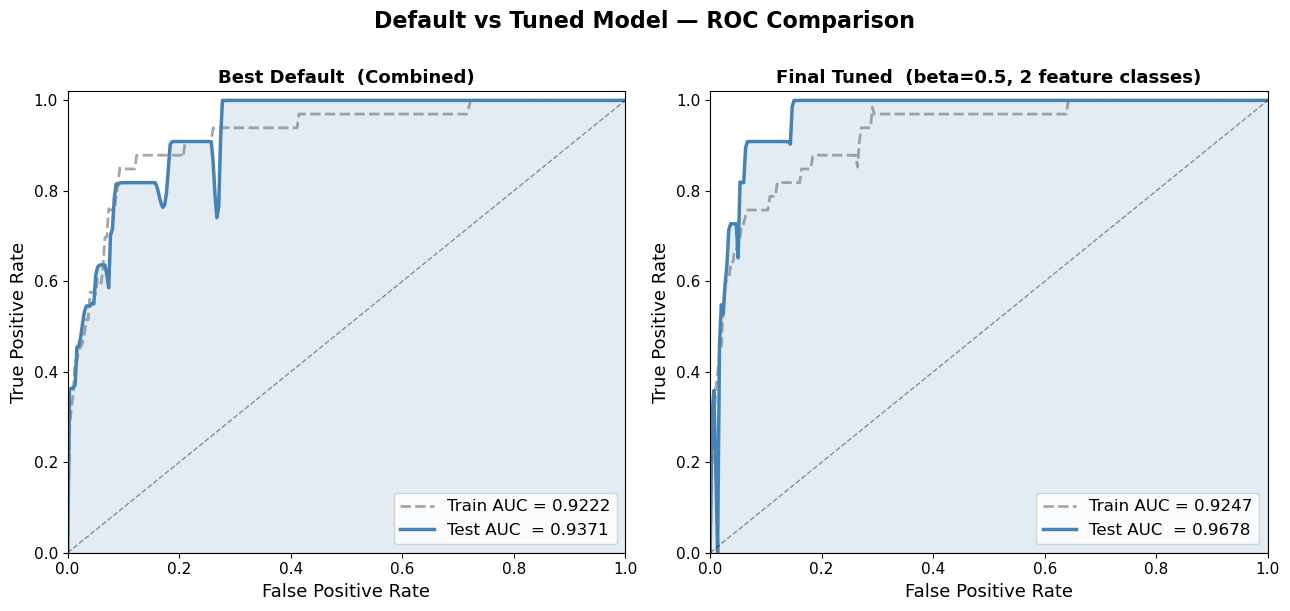

Saved -> Modeled/09_default_vs_tuned_roc.png


In [173]:
# -- Side-by-side ROC and metrics table: default vs final --------------
print(f'{"Metric":<20}  {"Best Default":>14}  {"Final (tuned)":>14}')
print('─' * 52)
for metric, key in [("Train AUC", "train_auc"), ("Test AUC", "test_auc"), ("AICc", "aicc")]:
    print(f'{metric:<20}  {BEST_SET_RESULT[key]:>14.4f}  {r_final[key]:>14.4f}')
print(f'{"AUC gap (tr-te)":<20}'
      f'  {BEST_SET_RESULT["train_auc"]-BEST_SET_RESULT["test_auc"]:>+14.4f}'
      f'  {r_final["train_auc"]-r_final["test_auc"]:>+14.4f}')
print()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, r, title in [
    (axes[0], BEST_SET_RESULT, f'Best Default  ({BEST_SET_RESULT["label"]})'),
    (axes[1], r_final,        f'Final Tuned  (beta={BEST_BETA}, {len(BEST_FEATURES)} feature classes)'),
]:
    fpr_tr_, tpr_tr_, _ = roc_curve(r["y_train"], r["y_prob_train"])
    _ftr_s, _ttr_s = _smooth_roc(fpr_tr_, tpr_tr_)
    _fte_s, _tte_s = _smooth_roc(r["fpr"], r["tpr"])
    ax.plot(_ftr_s, _ttr_s, color="grey", lw=2, ls="--", alpha=0.7,
            label=f'Train AUC = {r["train_auc"]:.4f}')
    ax.plot(_fte_s, _tte_s, color="steelblue", lw=2.5,
            label=f'Test AUC  = {r["test_auc"]:.4f}')
    ax.fill_between(_fte_s, _tte_s, alpha=0.15, color="steelblue")
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.4)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax.set_xlabel("False Positive Rate", fontsize=13)
    ax.set_ylabel("True Positive Rate", fontsize=13)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=12)
    ax.tick_params(labelsize=11)

plt.suptitle('Default vs Tuned Model — ROC Comparison',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, '09_default_vs_tuned_roc.png')
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f'Saved -> {out_path}')

A smaller AUC gap (train minus test) in the tuned model indicates better generalisation; lower AICc at comparable test AUC confirms the regularisation is effective.

### 6.2 Response Curves

Marginal response curves for the final model. Each predictor is swept across its 5th–95th percentile of training values while all others are held at their training-set mean. Panels sorted by permutation importance.

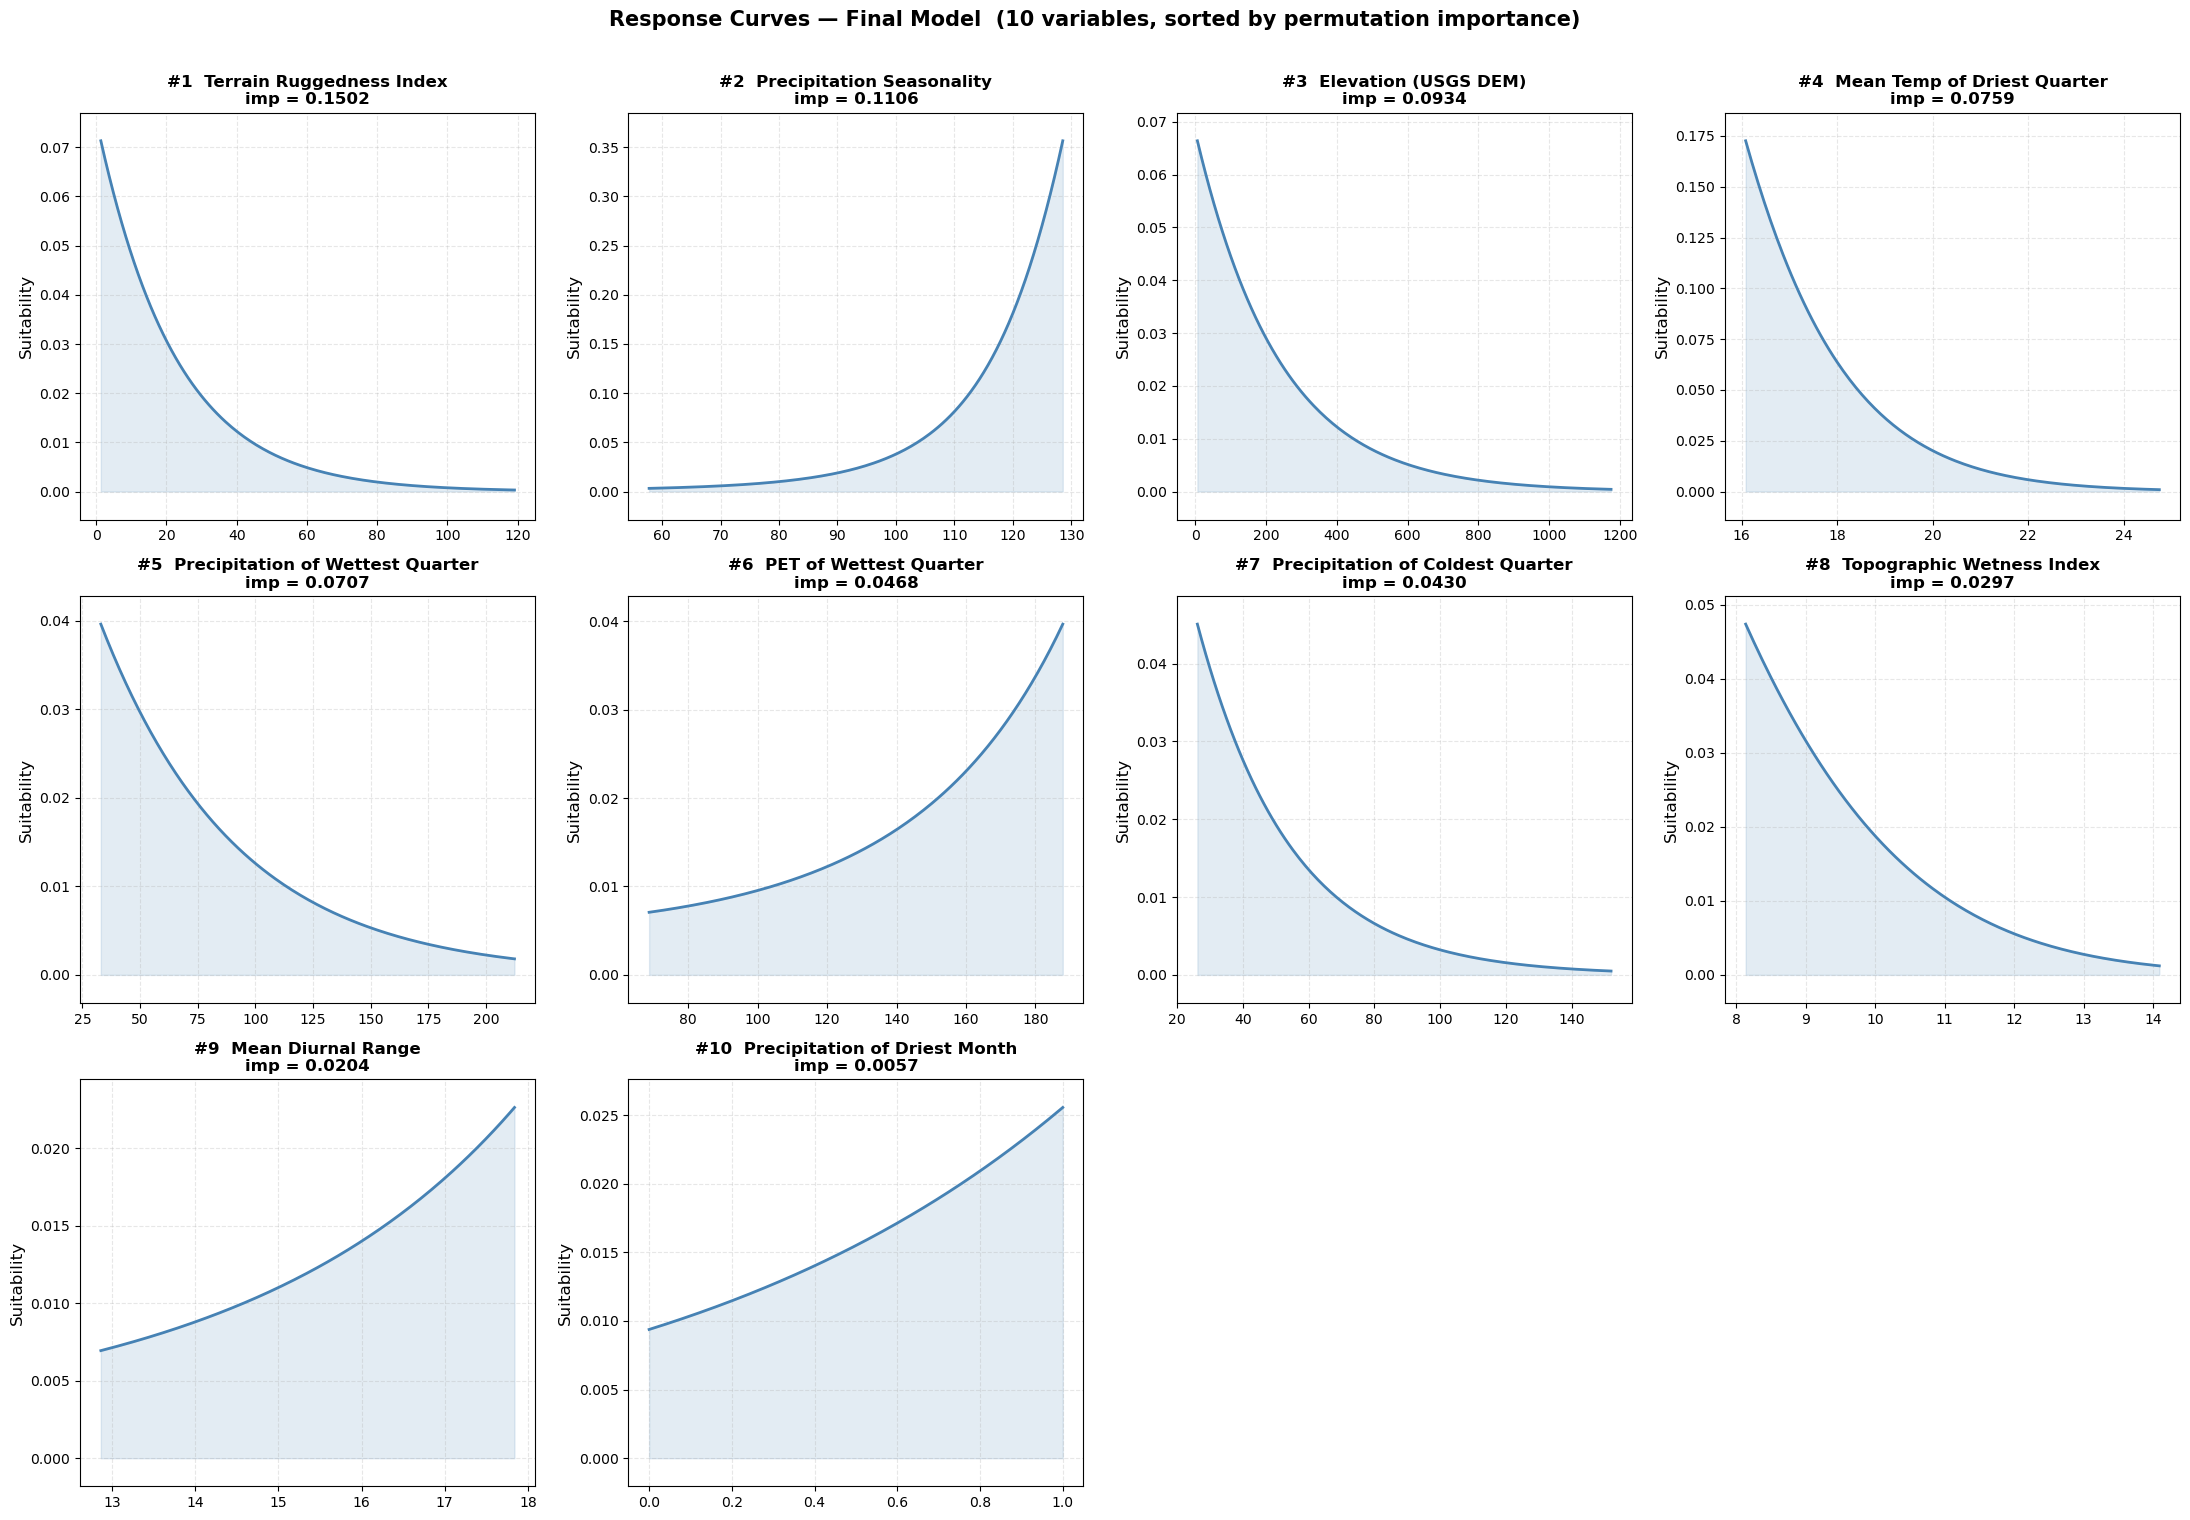

Saved -> Modeled/10_final_model_response_curves.png


In [174]:
# -- Response curves for all variables (final model) ------------------
imp_df_f  = r_final["perm_imp_df"].reset_index(drop=True)
model_f   = r_final["model"]
X_train_f = r_final["X_train"]
X_mean    = X_train_f[BEST_VARS].mean()

n_plot = len(BEST_VARS)
ncols  = 4
nrows  = math.ceil(n_plot / ncols)
fig, axes = plt.subplots(nrows, ncols,
                         figsize=(5.5 * ncols, 5 * nrows), squeeze=False)
ax_flat   = axes.flatten()

for idx, (_, row) in enumerate(imp_df_f.iterrows()):
    var  = row["Variable"]
    x_lo = X_train_f[var].quantile(0.05)
    x_hi = X_train_f[var].quantile(0.95)
    ax   = ax_flat[idx]

    if x_hi <= x_lo:
        ax.set_visible(False)
        continue

    x_range = np.linspace(x_lo, x_hi, 200)
    X_marg  = pd.DataFrame(np.tile(X_mean.values, (200, 1)), columns=BEST_VARS)
    X_marg[var] = x_range
    y_pred  = model_f.predict(X_marg)

    ax.plot(x_range, y_pred, color="steelblue", lw=2)
    ax.fill_between(x_range, y_pred, alpha=0.15, color="steelblue")
    ax.margins(y=0.08)
    ax.set_ylabel("Suitability", fontsize=12)
    ax.set_title(f'#{idx+1}  {_disp(var)}\nimp = {row["importance"]:.4f}',
                 fontsize=12, fontweight='bold', pad=6)
    ax.tick_params(labelsize=10)
    ax.grid(True, ls="--", alpha=0.3)

for ax in ax_flat[n_plot:]:
    ax.set_visible(False)

plt.suptitle(f'Response Curves — Final Model  ({len(BEST_VARS)} variables, sorted by permutation importance)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, '10_final_model_response_curves.png')
plt.savefig(out_path, dpi=150, bbox_inches="tight")
plt.show()
print(f'Saved -> {out_path}')

X axis spans the 5th–95th percentile of training values to avoid extrapolation artefacts. All other variables are held at their training-set mean.

### 6.3a Variable Importance (Permutation)

Permutation importance for the final tuned model: mean AUC decrease when each variable is randomly shuffled (10 repeats). Variables sorted by descending importance.

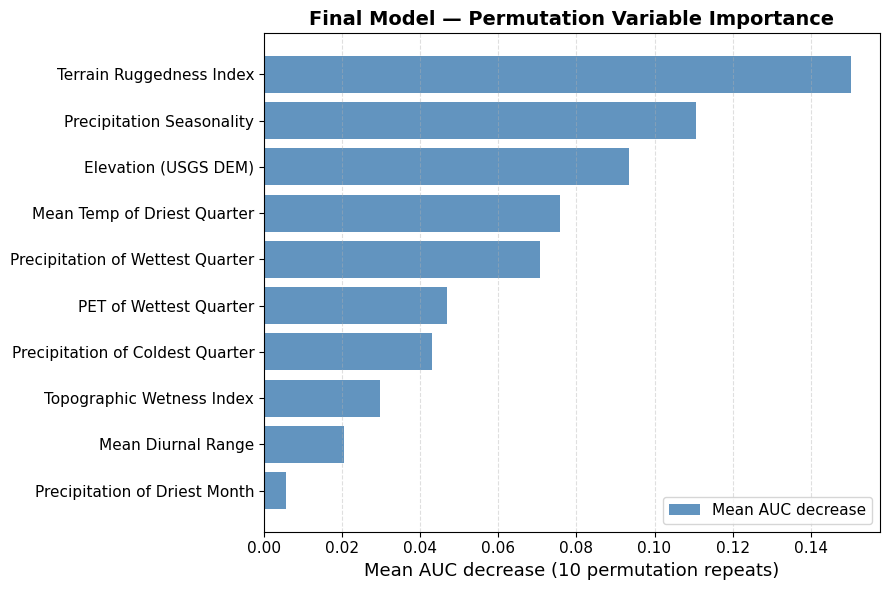

Saved -> Modeled/11_final_model_permutation_importance.png


In [175]:
# -- Permutation importance for the final model -------------------------
imp_df_f = r_final['perm_imp_df'].copy()
imp_df_f['label'] = imp_df_f['Variable'].map(_disp)

fig, ax = plt.subplots(figsize=(9, max(6, len(imp_df_f) * 0.50)))
ax.barh(imp_df_f['label'], imp_df_f['importance'],
        color='steelblue', alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel('Mean AUC decrease (10 permutation repeats)', fontsize=13)
ax.set_title('Final Model — Permutation Variable Importance',
             fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(axis='x', ls='--', alpha=0.4)
ax.legend(handles=[Patch(facecolor='steelblue', alpha=0.85, label='Mean AUC decrease')],
          loc='lower right', fontsize=11, frameon=True)
plt.tight_layout()
_perm_fig = os.path.join(OUTPUT_DIR, '11_final_model_permutation_importance.png')
plt.savefig(_perm_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved -> {_perm_fig}')

### 6.3b Jackknife Variable Importance

Jackknife for the final tuned model: AUC when using only this variable (blue) vs all variables except this one (red). The dashed line marks the full-model test AUC.

Jackknife — Final Model:   0%|          | 0/10 [00:00<?, ?it/s]

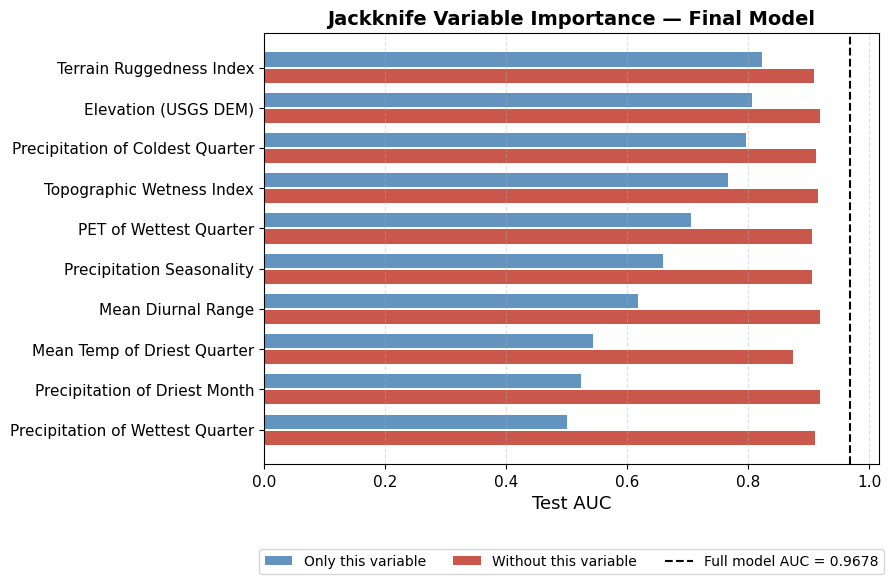

Saved → Modeled/12_final_model_jackknife.png


In [176]:
# -- Jackknife for the final model --------------------------------------
_jk_fig = os.path.join(OUTPUT_DIR, '12_final_model_jackknife.png')
run_jackknife(r_final, save_path=_jk_fig)

### 6.4 Suitability Raster

Applies the final model to the full raster stack and exports a GeoTIFF.

In [177]:
# -- Apply final model to full raster stack → GeoTIFF -----------------
suit_tif = os.path.join(OUTPUT_DIR, 'suitability_cloglog.tif')

elapid.apply_model_to_rasters(
    r_final["model"], raster_list_final,
    output_path=suit_tif, quiet=True,
)
print(f'Suitability raster saved -> {suit_tif}')

with rasterio.open(suit_tif) as src:
    suit_arr = src.read(1).astype(float)
    suit_nd  = src.nodata
    suit_bnd = src.bounds

suit_arr = np.where(suit_arr == suit_nd, np.nan, suit_arr)
print(f'  min  : {np.nanmin(suit_arr):.4f}')
print(f'  mean : {np.nanmean(suit_arr):.4f}')
print(f'  max  : {np.nanmax(suit_arr):.4f}')
print(f'  valid pixels : {(~np.isnan(suit_arr)).sum():,}')

Suitability raster saved -> Modeled/suitability_cloglog.tif
  min  : 0.0000
  mean : 0.1389
  max  : 1.0000
  valid pixels : 177,908


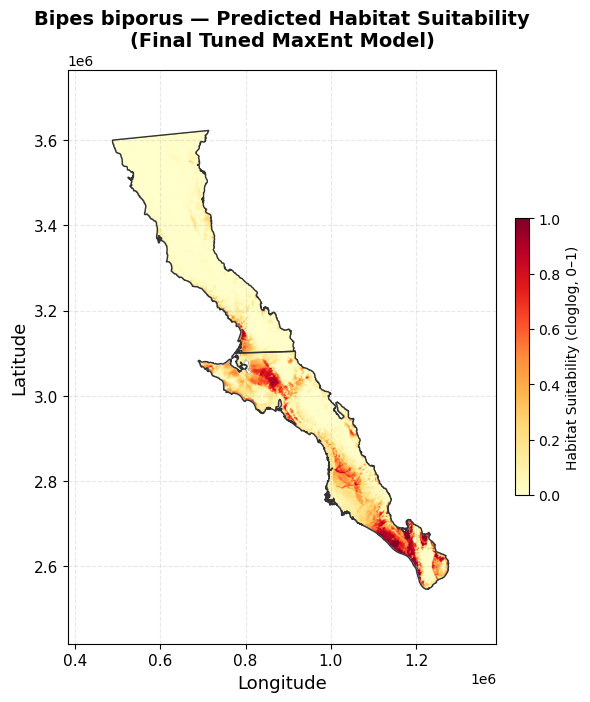

Saved → Modeled/13_Bipes_biporus_suitability.png


In [178]:
# -- Suitability map visualization ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 10))

im = ax.imshow(
    suit_arr, cmap='YlOrRd', vmin=0, vmax=1,
    extent=[suit_bnd.left, suit_bnd.right, suit_bnd.bottom, suit_bnd.top],
    origin='upper', aspect='equal',
)
study_area.plot(ax=ax, color='none', edgecolor='#333333', linewidth=1.0, zorder=2)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04,
             label='Habitat Suitability (cloglog, 0–1)')
ax.set_xlim(suit_bnd.left, suit_bnd.right)
ax.set_ylim(suit_bnd.bottom, suit_bnd.top)
ax.set_xlabel('Longitude', fontsize=13)
ax.set_ylabel('Latitude', fontsize=13)
ax.set_title(f'{SPECIES_NAME.replace("_", " ")} — Predicted Habitat Suitability\n'
             f'(Final Tuned MaxEnt Model)',
             fontsize=14, fontweight='bold')
ax.tick_params(labelsize=11)
ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, f'13_{SPECIES_NAME}_suitability.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')

## 7. Reclassify Suitability

### 7.1 Threshold
> ✎ **Edit `SUITABILITY_THRESHOLD` before running this section.**
> Set a value between 0 and 1: pixels ≥ threshold → suitable (1), below → unsuitable (0).
> Common starting points: `0.5` (neutral midpoint), or the minimum suitability score at a known presence location.

Threshold         : 0.5
Suitable pixels   : 16,608  (9.3 %)
Unsuitable pixels : 161,300
Binary raster saved → Modeled/suitability_binary.tif


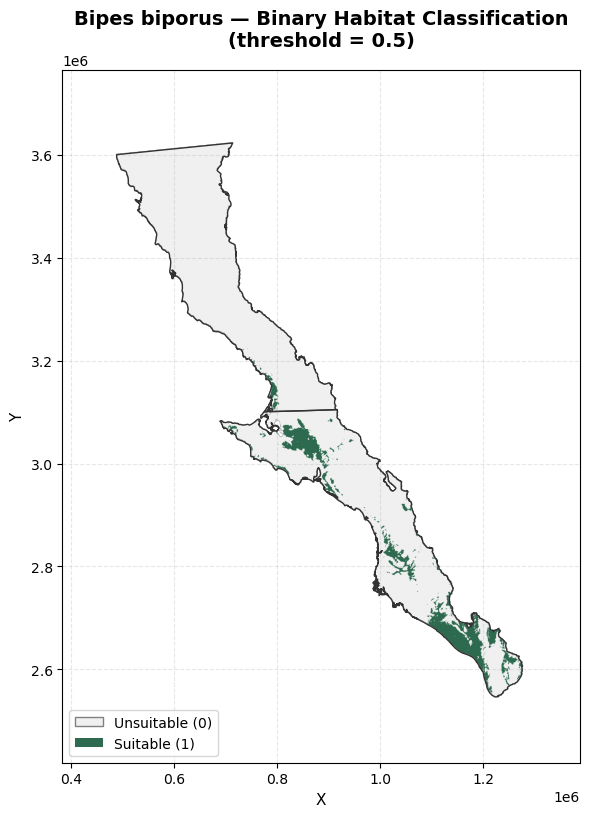

Saved → Modeled/14_Bipes_biporus_suitability_binary.png


In [179]:
SUITABILITY_THRESHOLD = 0.5   # ← pixels with suitability ≥ this value → suitable (1); below → unsuitable (0)

# ── Apply threshold (NaN pixels stay NaN) ─────────────────────────────────────
binary_arr = np.where(np.isnan(suit_arr), np.nan,
                      np.where(suit_arr >= SUITABILITY_THRESHOLD, 1.0, 0.0))

n_suitable   = int(np.nansum(binary_arr == 1))
n_unsuitable = int(np.nansum(binary_arr == 0))
print(f'Threshold         : {SUITABILITY_THRESHOLD}')
print(f'Suitable pixels   : {n_suitable:,}  ({100 * n_suitable / (n_suitable + n_unsuitable):.1f} %)')
print(f'Unsuitable pixels : {n_unsuitable:,}')

# ── Save binary GeoTIFF ────────────────────────────────────────────────────────
binary_tif = os.path.join(OUTPUT_DIR, 'suitability_binary.tif')
with rasterio.open(suit_tif) as src:
    profile = src.profile.copy()
    profile.update(dtype='float32', nodata=np.nan)
with rasterio.open(binary_tif, 'w', **profile) as dst:
    dst.write(binary_arr.astype(np.float32), 1)
print(f'Binary raster saved → {binary_tif}')

# ── Binary map ────────────────────────────────────────────────────────────────
extent = [suit_bnd.left, suit_bnd.right, suit_bnd.bottom, suit_bnd.top]
fig, ax = plt.subplots(figsize=(6, 10))
cmap_bin = mcolors.ListedColormap(['#f0f0f0', '#2d6a4f'])
ax.imshow(binary_arr, cmap=cmap_bin, vmin=0, vmax=1,
          extent=extent, origin='upper', aspect='equal')
study_area.plot(ax=ax, color='none', edgecolor='#333333', linewidth=1.0, zorder=2)
ax.legend(handles=[Patch(facecolor='#f0f0f0', edgecolor='grey', label='Unsuitable (0)'),
                   Patch(facecolor='#2d6a4f', label='Suitable (1)')],
          loc='lower left', fontsize=10)
ax.set_title(f'{SPECIES_NAME.replace("_", " ")} — Binary Habitat Classification\n'
             f'(threshold = {SUITABILITY_THRESHOLD})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('X', fontsize=11); ax.set_ylabel('Y', fontsize=11)
ax.tick_params(labelsize=10); ax.grid(True, ls='--', alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, f'14_{SPECIES_NAME}_suitability_binary.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out_path}')